<a href="https://colab.research.google.com/github/gabrieladamasceno/ZERO-DAY-ATTACK-DETECTION-6G/blob/main/NetsLab_5G/NetsLab_5G_Autoencoder_All_Attacks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Acessar dataset
drive.mount('/content/gdrive')

# Carregar o dataset
encoded = pd.read_csv("/content/gdrive/MyDrive/Datasets/Attacks/ORAN/Network_Dataset.csv")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import pandas as pd


print(f"Total de colunas: {len(encoded.columns)}\n")
print(encoded.columns.tolist())

Total de colunas: 26

['uid', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'history', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'ip_proto', 'http_trans_depth', 'attack_category', 'attack_type', 'files_total_bytes', 'is_GET_mthd', 'http_status_error', 'is_file_transfered', 'traffic_type']


In [ ]:
import pandas as pd

# Ver todos os tipos de ataque (categorias amplas)
print("Categorias de ataque:")
print(encoded['attack_category'].unique())

# Contar ocorrência de cada categoria
print("\nContagem por categoria:")
print(encoded['attack_category'].value_counts())

# Ver todos os tipos específicos de ataque
print("\nTipos específicos de ataque:")
print(encoded['attack_type'].unique())

# Contar ocorrência de cada tipo específico
print("\nContagem por tipo:")
print(encoded['attack_type'].value_counts())

Categorias de ataque:
['ddos' 'bruteforce' 'probe' 'web' 'dos' 'benign']

Contagem por categoria:
attack_category
dos           632507
ddos          420282
web           288304
probe         183293
benign        170865
bruteforce     28566
Name: count, dtype: int64

Tipos específicos de ataque:
['tcp_ack' 'syn' 'icmp' 'slowloris' 'udp' 'ssh' 'ftp' 'portscan_tcp'
 'os_fingerprinting' 'portscan_udp' 'http_flood' 'dir_bruteforce' 'benign'
 'xss' 'sql_injection']

Contagem por tipo:
attack_type
syn                  506451
http_flood           254314
udp                  227408
tcp_ack              199304
benign               170865
portscan_tcp         100000
slowloris             94887
os_fingerprinting     62957
dir_bruteforce        28566
icmp                  24739
portscan_udp          20336
ssh                   14902
ftp                   13664
xss                    3661
sql_injection          1763
Name: count, dtype: int64


In [ ]:
pip install imbalanced-learn


In [ ]:
!pip install --upgrade tensorflow
!pip install --upgrade keras

In [ ]:
!pip install gputil


In [ ]:
# Selecionar apenas colunas numéricas
numeric_cols = encoded.select_dtypes(include=['number']).columns

# Aplicar a suavização apenas nas colunas numéricas
for col in numeric_cols:
    encoded[col] = encoded[col].fillna(encoded[col].mean())

In [ ]:
# columns with null values

columns_null = []
columns = encoded.columns
for column in columns:
    c = encoded[column].isnull().sum()
    if c != 0:
        print(column, 'has {} null values'.format(c))
        columns_null.append(column)

In [ ]:
import psutil
import time
import numpy as np
import pandas as pd
import gc
import tensorflow as tf
import subprocess
import matplotlib.pyplot as plt
from keras.callbacks import Callback
from keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import backend as K

# ===== Monitor Resource =====
def monitor_resource_usage():
    process = psutil.Process()
    memory_info = process.memory_info()
    cpu_percent = psutil.cpu_percent(interval=0.1)
    memory_usage_mb = memory_info.rss / (1024 * 1024)
    return cpu_percent, memory_usage_mb

def calcular_energia(cpu_usage, freq_ghz, tempo_exec_s, theta=1.0, z=1e-27):
    freq_hz = freq_ghz * 1e9
    carga = cpu_usage * theta * freq_hz
    energia_joules = z * (carga ** 3) * tempo_exec_s
    return energia_joules

# ===== Training =====
class ResourceMonitor(Callback):
    def on_train_begin(self, logs=None):
        self.cpu_usage = []
        self.memory_usage = []
        self.energy_usage = []
        self.start_time = time.time()
        print("\n[Start of Training]")

    def on_epoch_begin(self, epoch, logs=None):
        cpu, mem = monitor_resource_usage()
        self.cpu_usage.append(cpu)
        self.memory_usage.append(mem)
        print(f"\n[Epoch {epoch + 1} - Start] CPU: {cpu:.2f}%, Memory: {mem:.2f} MB")

    def on_epoch_end(self, epoch, logs=None):
        cpu, mem = monitor_resource_usage()
        self.cpu_usage.append(cpu)
        self.memory_usage.append(mem)
        frequencia_cpu_ghz = 2.0
        tempo_execucao_epoca = time.time() - self.start_time
        print(f"[Epoch {epoch + 1} - End] CPU: {cpu:.2f}%, Memory: {mem:.2f} MB")

        gc.collect()
        K.clear_session()

    def on_train_end(self, logs=None):
        total_time = time.time() - self.start_time
        avg_cpu = np.mean(self.cpu_usage)
        avg_mem = np.mean(self.memory_usage)

        frequencia_cpu_ghz = 2.0

        energia = calcular_energia(avg_cpu, frequencia_cpu_ghz, total_time)

        print("\n[End of Training]")
        print(f"Total time: {total_time:.2f} seconds")
        print(f"Average CPU usage (Training): {avg_cpu:.2f}%")
        print(f"Average memory usage (Training): {avg_mem:.2f} MB")
        print(f"Estimated energy consumption: {energia:.2f} Joules")

        self.total_time = total_time
        self.avg_cpu = avg_cpu
        self.avg_mem = avg_mem
        self.energia = energia

        self._plot_usage()

    def _plot_usage(self):
        epochs = list(range(1, len(self.cpu_usage) + 1))

        plt.figure(figsize=(14, 5))

        # CPU
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.cpu_usage, marker='o', linestyle='-', color='tab:blue', label='CPU Usage')
        plt.xlabel("Epoch")
        plt.ylabel("CPU Usage (%)")
        plt.title("CPU Consumption (Train)")
        plt.legend()
        plt.grid(True)

        # Memória
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.memory_usage, marker='o', linestyle='-', color='tab:red', label='Memory Usage')
        plt.xlabel("Epoch")
        plt.ylabel("Memory (MB)")
        plt.title("Memory Consumption (Train)")
        plt.legend()
        plt.grid(True)


        plt.tight_layout()
        plt.savefig("resource_usage_train.png")
        plt.show()
        plt.clf()
        plt.close()


# ===== Prediction/Test =====
def monitor_test_prediction(model, X_test):
    cpu_usage_test = []
    memory_usage_test = []

    print("\n[Start of Prediction/Test]")
    start_time = time.time()

    step_size = max(1, len(X_test) // 10)
    for i in range(0, len(X_test), step_size):
        end_i = min(i + step_size, len(X_test))
        monitor_cpu, monitor_mem = monitor_resource_usage()
        cpu_usage_test.append(monitor_cpu)
        memory_usage_test.append(monitor_mem)
        _ = model.predict(X_test[i:end_i], verbose=0)

    total_time_test = time.time() - start_time
    avg_cpu_test = np.mean(cpu_usage_test)
    avg_mem_test = np.mean(memory_usage_test)

    frequencia_cpu_ghz = 2.0

    # Energy
    energia_test = calcular_energia(avg_cpu_test, frequencia_cpu_ghz, total_time_test)

    print("\n[End of Prediction/Test]")
    print(f"Total time: {total_time_test:.2f} seconds")
    print(f"Average CPU usage (Test): {avg_cpu_test:.2f}%")
    print(f"Average memory usage (Test): {avg_mem_test:.2f} MB")
    print(f"Estimated energy consumption: {energia_test:.2f} Joules")

    # Graphs
    plt.figure(figsize=(14, 5))

    # CPU
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(cpu_usage_test) + 1), cpu_usage_test, marker='o', linestyle='-', color='tab:blue', label='CPU Usage (Test)')
    plt.xlabel("Prediction Block")
    plt.ylabel("CPU Usage (%)")
    plt.title("CPU Consumption (Test)")
    plt.legend()
    plt.grid(True)

    # Memory
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(memory_usage_test) + 1), memory_usage_test, marker='o', linestyle='-', color='tab:red', label='Memory Usage (Test)')
    plt.xlabel("Prediction Block")
    plt.ylabel("Memory (MB)")
    plt.title("Memory Consumption (Test)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("resource_usage_test.png")
    plt.show()
    plt.clf()
    plt.close()

    return {
    'total_time': total_time_test,
    'avg_cpu': avg_cpu_test,
    'avg_mem': avg_mem_test,
    'energia': energia_test
    }

resource_monitor = ResourceMonitor()

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

In [ ]:
print(encoded['traffic_type'].unique())

[1 0]


In [ ]:
# Binary Label: 0 = benign, 1 = attack
encoded['Label'] = encoded['traffic_type'].apply(lambda x: 0 if x == 0 else 1)

print(encoded[['traffic_type', 'Label']].head(10))
print("\nClass:")
print(encoded['Label'].value_counts())

   traffic_type  Label
0             1      1
1             1      1
2             1      1
3             1      1
4             1      1
5             1      1
6             1      1
7             1      1
8             1      1
9             1      1

Class:
Label
1    1552952
0     170865
Name: count, dtype: int64



====== Zero-Day: tcp_ack ======
Total tcp_ack in the original dataset: 199304
  Zero-days removed from training: 159722
  Zero-day in the original test: 39582
  Test full total: 344764

[Start of Training]

[Epoch 1 - Start] CPU: 0.00%, Memory: 4006.97 MB
[Epoch 1 - End] CPU: 1.30%, Memory: 3854.10 MB

[Epoch 2 - Start] CPU: 0.00%, Memory: 3854.06 MB
[Epoch 2 - End] CPU: 1.20%, Memory: 3911.60 MB

[Epoch 3 - Start] CPU: 13.70%, Memory: 3911.58 MB
[Epoch 3 - End] CPU: 0.00%, Memory: 3940.46 MB

[Epoch 4 - Start] CPU: 0.00%, Memory: 3940.44 MB
[Epoch 4 - End] CPU: 0.00%, Memory: 3967.42 MB

[Epoch 5 - Start] CPU: 1.20%, Memory: 3967.40 MB
[Epoch 5 - End] CPU: 0.00%, Memory: 3994.73 MB

[Epoch 6 - Start] CPU: 0.00%, Memory: 3994.71 MB
[Epoch 6 - End] CPU: 17.50%, Memory: 4023.39 MB

[Epoch 7 - Start] CPU: 15.20%, Memory: 4023.37 MB
[Epoch 7 - End] CPU: 0.00%, Memory: 4052.66 MB

[Epoch 8 - Start] CPU: 0.00%, Memory: 4052.64 MB
[Epoch 8 - End] CPU: 0.00%, Memory: 4081.29 MB

[Epoch 9 - St

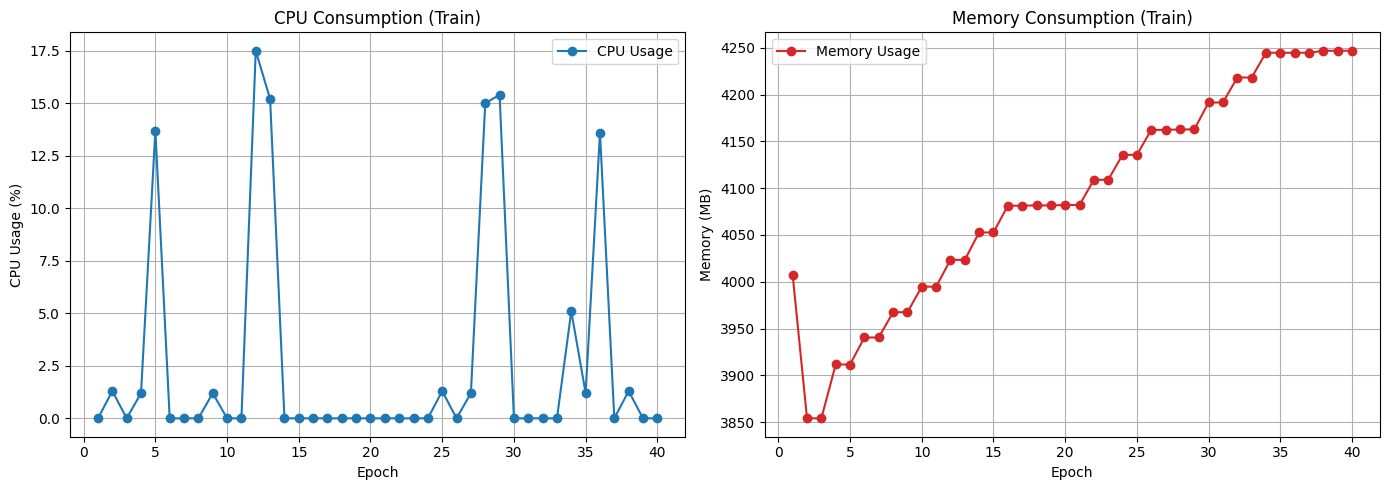

67676/67676 ━━━━━━━━━━━━━━━━━━━━ 87s 1ms/step

====== General Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 16.50 seconds
Average CPU usage (Test): 3.40%
Average memory usage (Test): 4448.52 MB
Estimated energy consumption: 5186.68 Joules


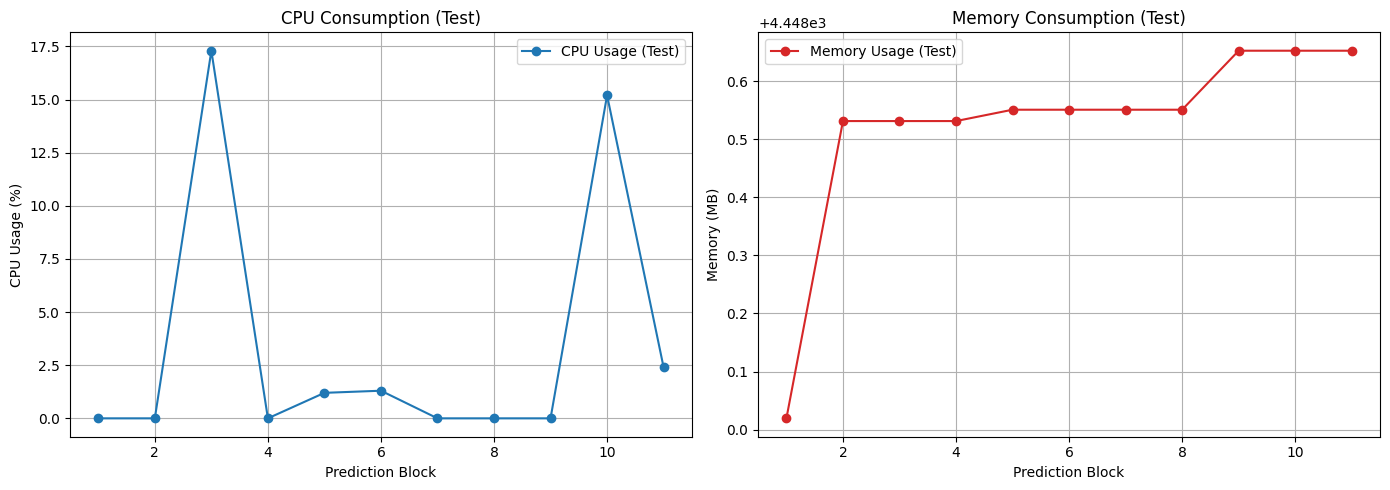

10774/10774 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step

====== Zero-Day Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 3.54 seconds
Average CPU usage (Test): 1.03%
Average memory usage (Test): 4416.63 MB
Estimated energy consumption: 30.66 Joules


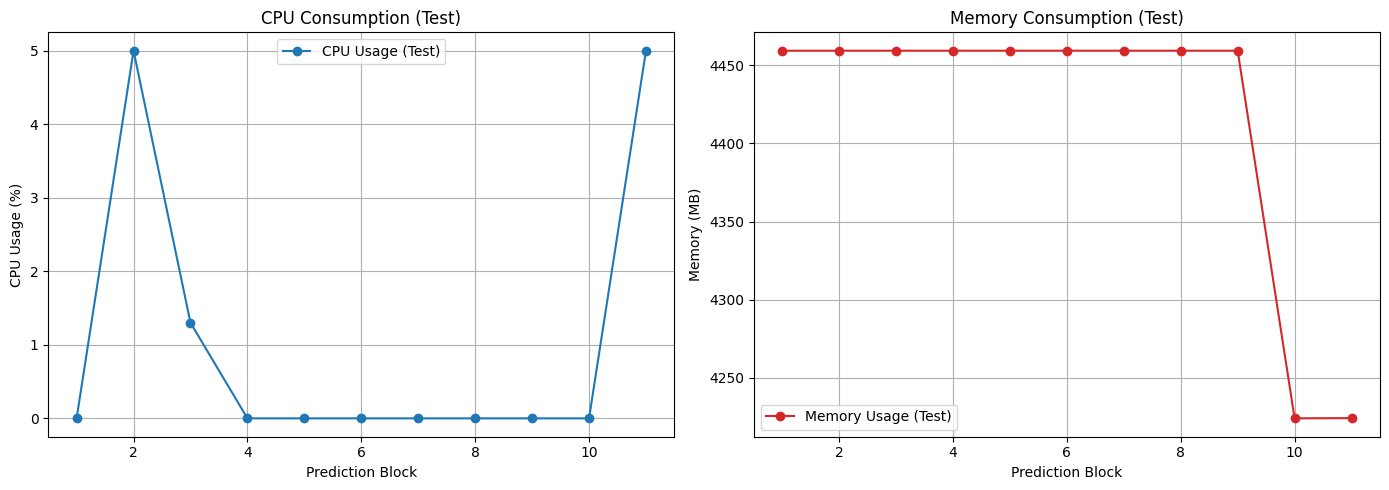

1237/1237 ━━━━━━━━━━━━━━━━━━━━ 1s 991us/step
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 9s 852us/step
STD reconstruction error: 150.8082232038786
ROC FULL=0.5953
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 9s 789us/step
STD reconstruction error: 150.8082232038786
PR FULL=0.9154

====== Zero-Day: syn ======
Total syn in the original dataset: 506451
  Zero-days removed from training: 405095
  Zero-day in the original test: 101356
  Test full total: 344764

[Start of Training]

[Epoch 1 - Start] CPU: 3.70%, Memory: 4697.83 MB
[Epoch 1 - End] CPU: 16.00%, Memory: 4336.62 MB

[Epoch 2 - Start] CPU: 0.00%, Memory: 4336.59 MB
[Epoch 2 - End] CPU: 0.00%, Memory: 4348.09 MB

[Epoch 3 - Start] CPU: 0.00%, Memory: 4348.06 MB
[Epoch 3 - End] CPU: 0.00%, Memory: 4348.88 MB

[Epoch 4 - Start] CPU: 1.20%, Memory: 4348.86 MB
[Epoch 4 - End] CPU: 3.70%, Memory: 4361.04 MB

[Epoch 5 - Start] CPU: 0.00%, Memory: 4361.02 MB
[Epoch 5 - End] CPU: 0.00%, Memory: 4361.90 MB

[Epoch 6 - Start] CPU: 1.30%, Memory: 4361.88 MB
[Epoch

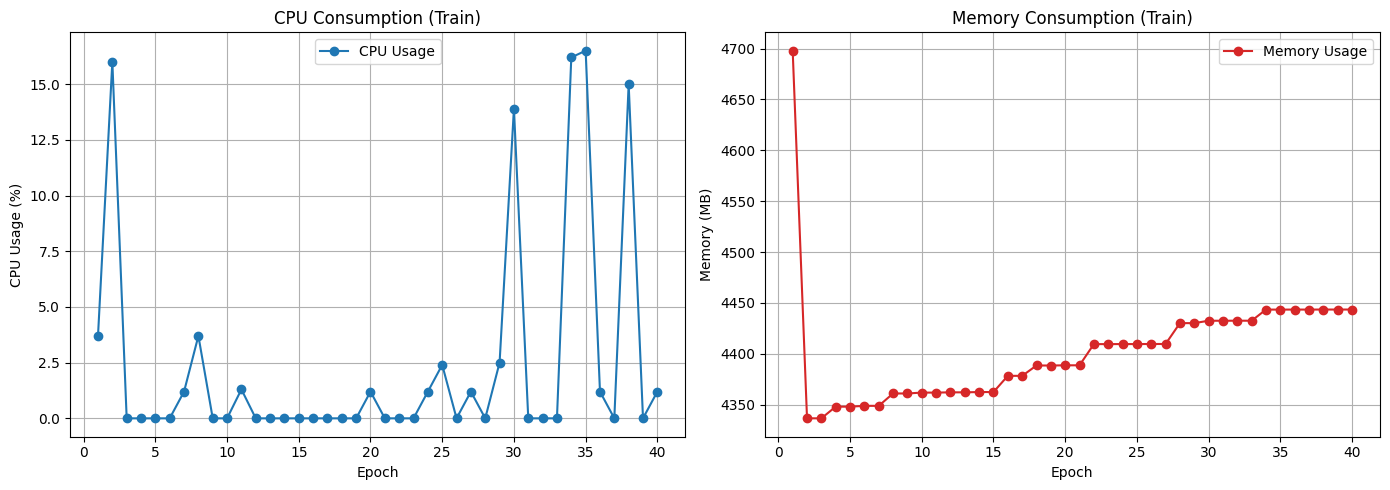

52340/52340 ━━━━━━━━━━━━━━━━━━━━ 67s 1ms/step

====== General Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 20.49 seconds
Average CPU usage (Test): 2.45%
Average memory usage (Test): 4505.60 MB
Estimated energy consumption: 2423.55 Joules


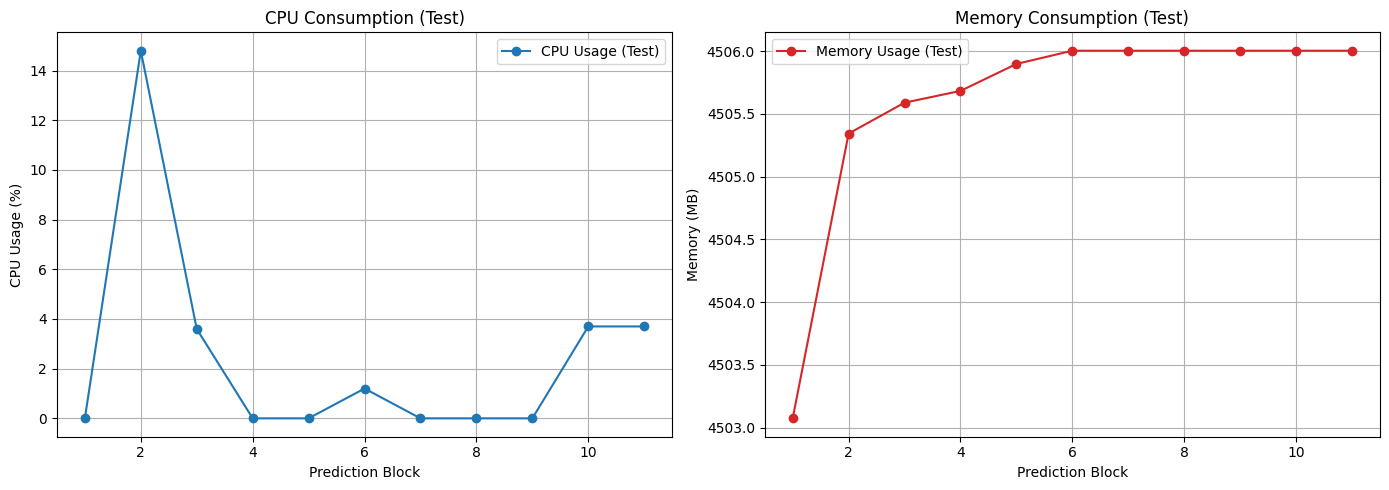

10774/10774 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step

====== Zero-Day Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 6.61 seconds
Average CPU usage (Test): 4.71%
Average memory usage (Test): 4348.51 MB
Estimated energy consumption: 5518.42 Joules


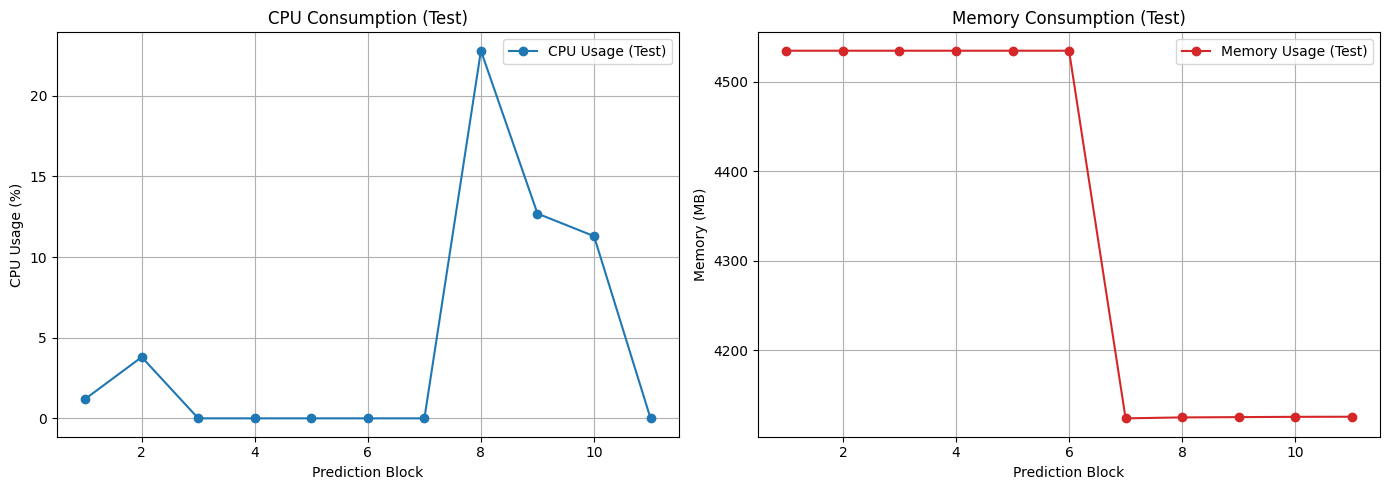

3168/3168 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step
STD reconstruction error: 129.72610610027544
ROC FULL=0.5660
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step
STD reconstruction error: 129.72610610027544
PR FULL=0.9011

====== Zero-Day: icmp ======
Total icmp in the original dataset: 24739
  Zero-days removed from training: 19756
  Zero-day in the original test: 4983
  Test full total: 344764

[Start of Training]

[Epoch 1 - Start] CPU: 12.50%, Memory: 5300.37 MB
[Epoch 1 - End] CPU: 12.50%, Memory: 4845.05 MB

[Epoch 2 - Start] CPU: 16.30%, Memory: 4845.02 MB
[Epoch 2 - End] CPU: 0.00%, Memory: 4888.73 MB

[Epoch 3 - Start] CPU: 0.00%, Memory: 4888.70 MB
[Epoch 3 - End] CPU: 0.00%, Memory: 4919.03 MB

[Epoch 4 - Start] CPU: 0.00%, Memory: 4919.01 MB
[Epoch 4 - End] CPU: 0.00%, Memory: 4938.05 MB

[Epoch 5 - Start] CPU: 5.00%, Memory: 4938.03 MB
[Epoch 5 - End] CPU: 0.00%, Memory: 4977.77 MB

[End of Training]
Total time: 207.75 seconds
Average CPU 

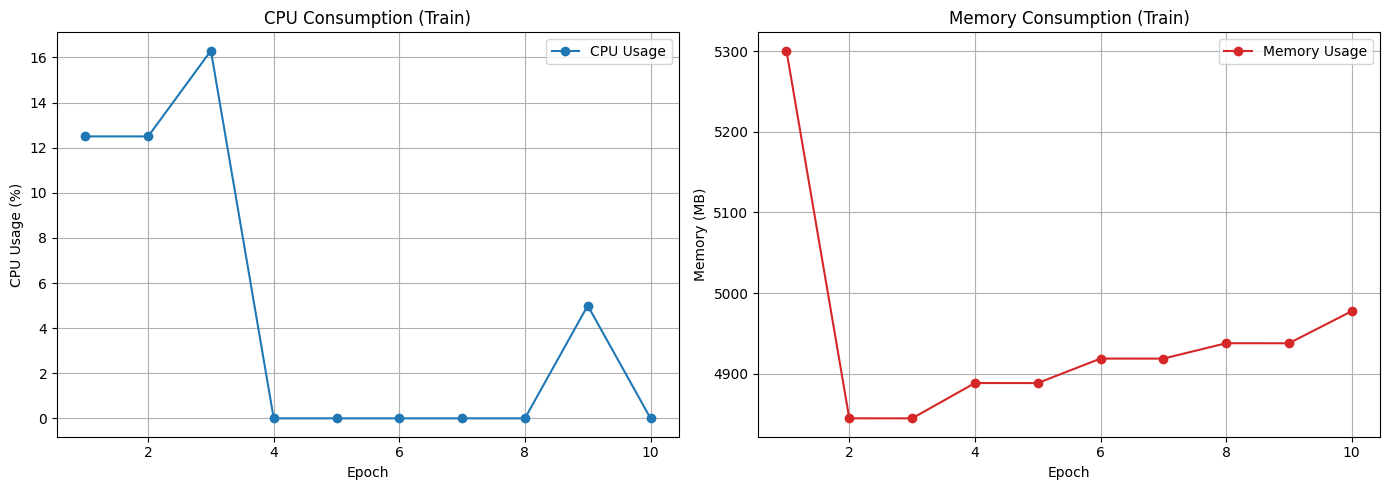

76424/76424 ━━━━━━━━━━━━━━━━━━━━ 66s 867us/step

====== General Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 15.62 seconds
Average CPU usage (Test): 1.68%
Average memory usage (Test): 4980.93 MB
Estimated energy consumption: 594.54 Joules


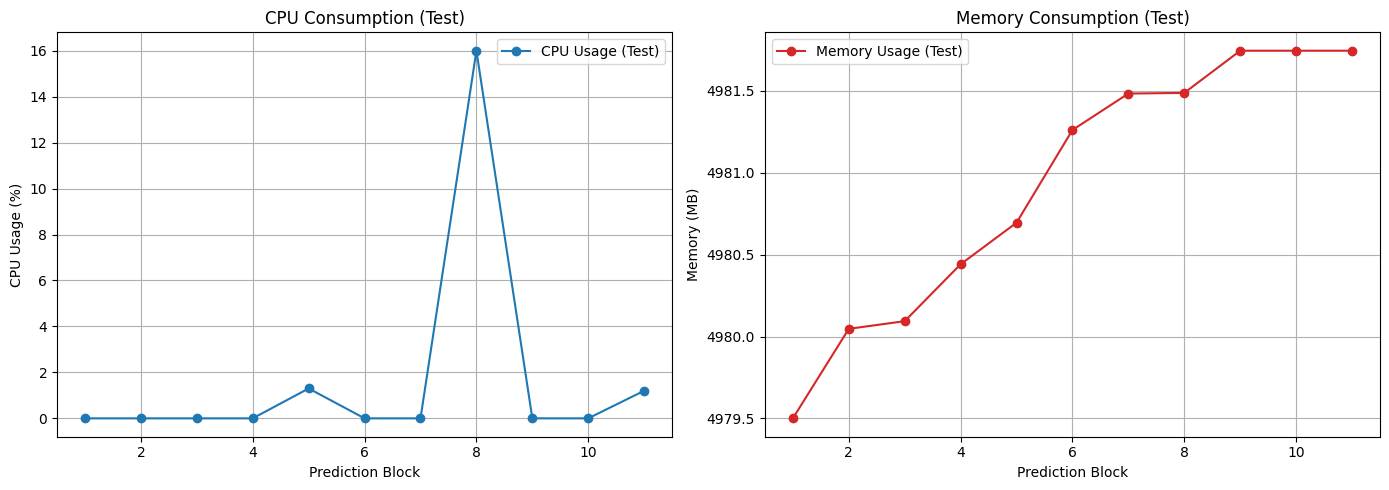

10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 935us/step

====== Zero-Day Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 2.42 seconds
Average CPU usage (Test): 9.75%
Average memory usage (Test): 4777.75 MB
Estimated energy consumption: 17943.35 Joules


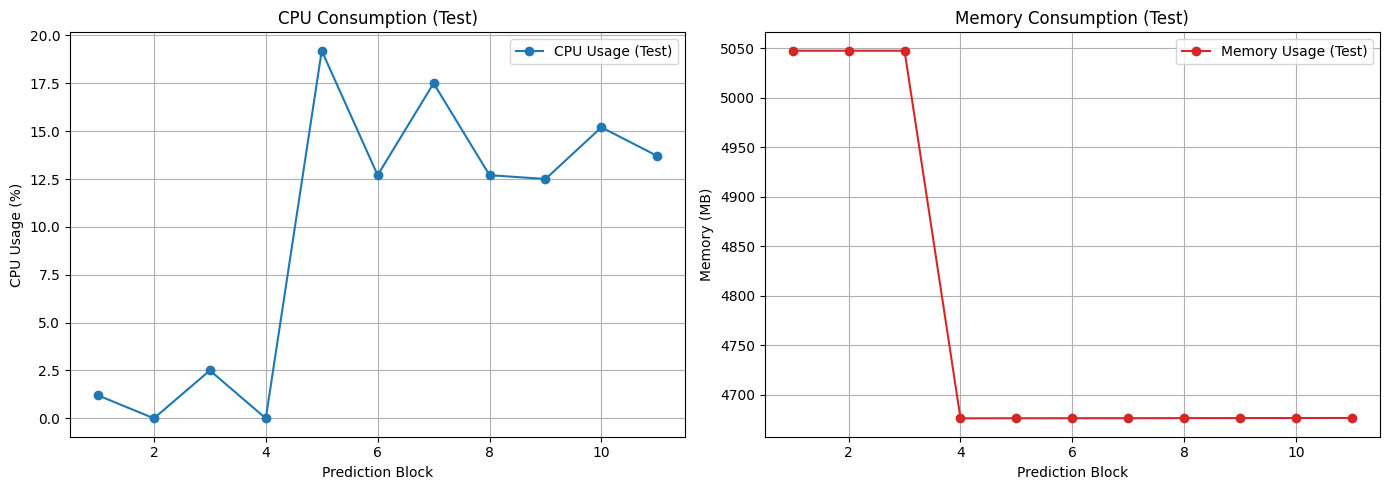

156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 936us/step
STD reconstruction error: 283.08443902039886
ROC FULL=0.6008
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 901us/step
STD reconstruction error: 283.08443902039886
PR FULL=0.9182

====== Zero-Day: slowloris ======
Total slowloris in the original dataset: 94887
  Zero-days removed from training: 75934
  Zero-day in the original test: 18953
  Test full total: 344764

[Start of Training]

[Epoch 1 - Start] CPU: 0.00%, Memory: 5518.68 MB
[Epoch 1 - End] CPU: 0.00%, Memory: 4965.83 MB

[Epoch 2 - Start] CPU: 1.20%, Memory: 4965.80 MB
[Epoch 2 - End] CPU: 13.80%, Memory: 5029.27 MB

[Epoch 3 - Start] CPU: 16.30%, Memory: 5029.24 MB
[Epoch 3 - End] CPU: 13.60%, Memory: 5058.36 MB

[Epoch 4 - Start] CPU: 13.70%, Memory: 5058.33 MB
[Epoch 4 - End] CPU: 0.00%, Memory: 5090.76 MB

[Epoch 5 - Start] CPU: 12.50%, Memory: 5090.74 MB
[Epoch 5 - End] CPU: 16.70%, Memory: 5123.08 MB

[End of Training]
Total time: 182.92 seco

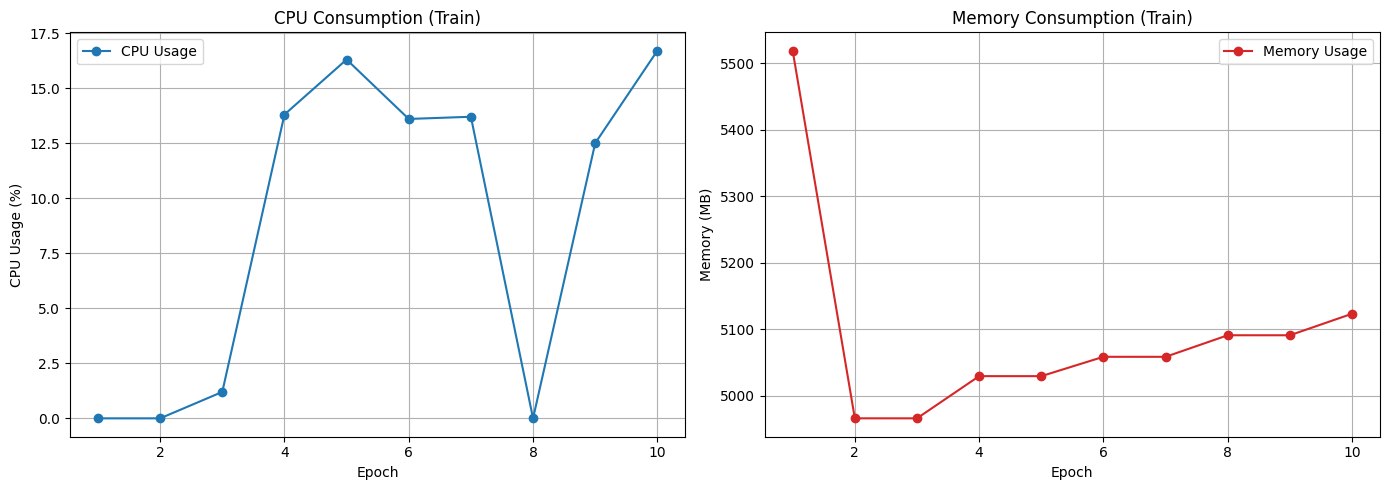

72912/72912 ━━━━━━━━━━━━━━━━━━━━ 76s 1ms/step

====== General Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 14.85 seconds
Average CPU usage (Test): 3.05%
Average memory usage (Test): 5126.93 MB
Estimated energy consumption: 3386.25 Joules


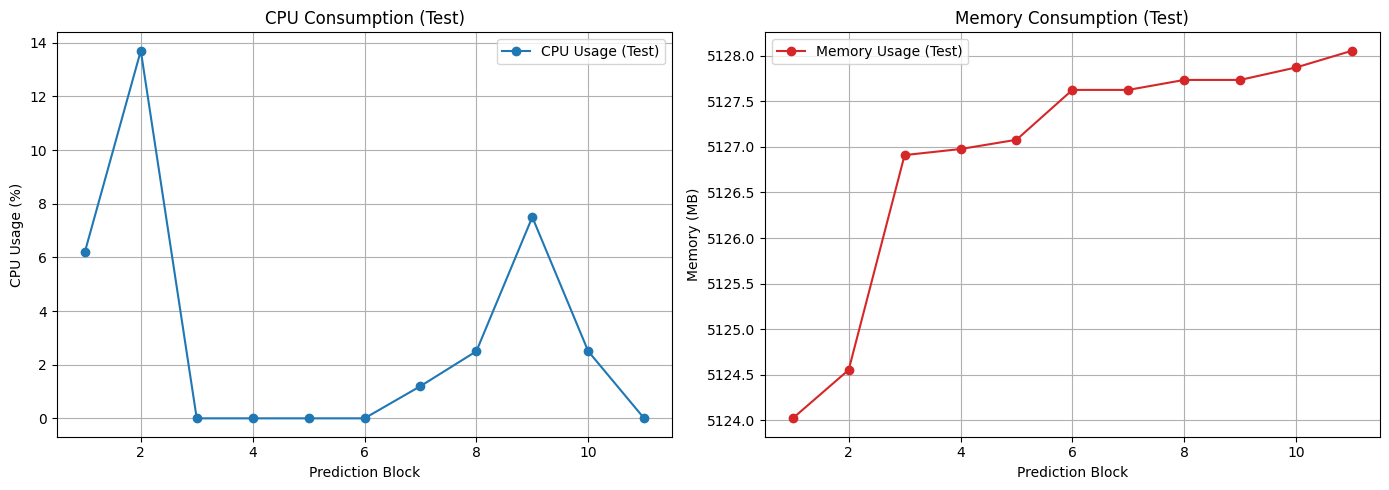

10774/10774 ━━━━━━━━━━━━━━━━━━━━ 9s 860us/step

====== Zero-Day Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 2.84 seconds
Average CPU usage (Test): 1.01%
Average memory usage (Test): 5011.90 MB
Estimated energy consumption: 23.31 Joules


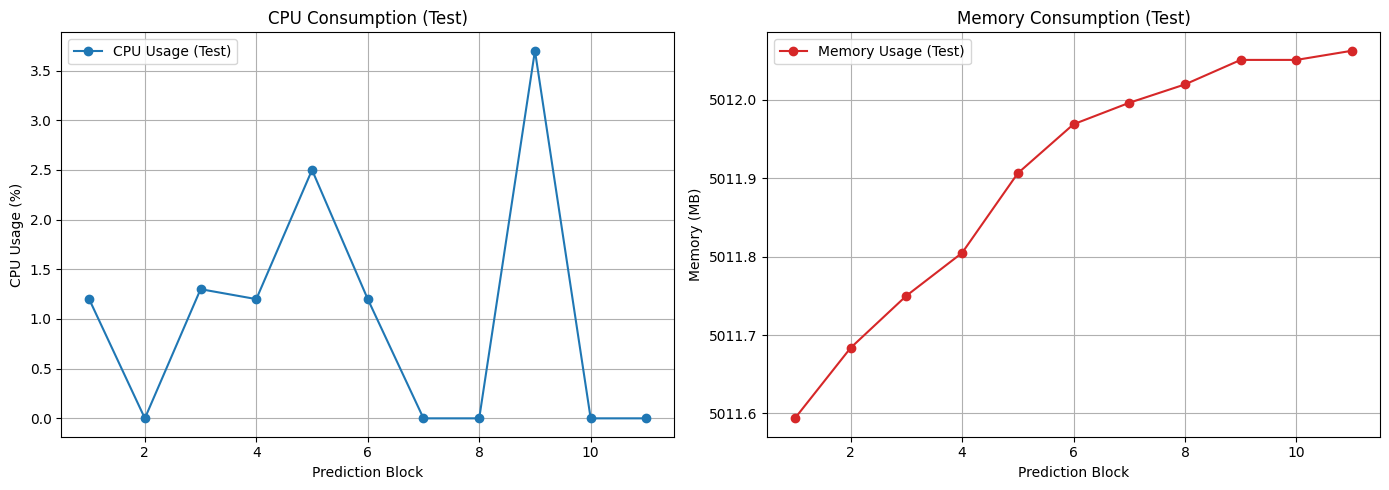

593/593 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 958us/step
STD reconstruction error: 283.8496201107184
ROC FULL=0.6181
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 9s 859us/step
STD reconstruction error: 283.8496201107184
PR FULL=0.9202

====== Zero-Day: udp ======
Total udp in the original dataset: 227408
  Zero-days removed from training: 181655
  Zero-day in the original test: 45753
  Test full total: 344764

[Start of Training]

[Epoch 1 - Start] CPU: 16.20%, Memory: 5477.93 MB
[Epoch 1 - End] CPU: 16.90%, Memory: 5073.69 MB

[Epoch 2 - Start] CPU: 13.80%, Memory: 5073.69 MB
[Epoch 2 - End] CPU: 0.00%, Memory: 5114.90 MB

[Epoch 3 - Start] CPU: 1.20%, Memory: 5114.88 MB
[Epoch 3 - End] CPU: 0.00%, Memory: 5154.75 MB

[Epoch 4 - Start] CPU: 13.80%, Memory: 5154.73 MB
[Epoch 4 - End] CPU: 0.00%, Memory: 5181.02 MB

[Epoch 5 - Start] CPU: 1.20%, Memory: 5180.99 MB
[Epoch 5 - End] CPU: 4.90%, Memory: 5184.68 MB

[End of Training]
Total time: 155.58 seconds
Average CPU

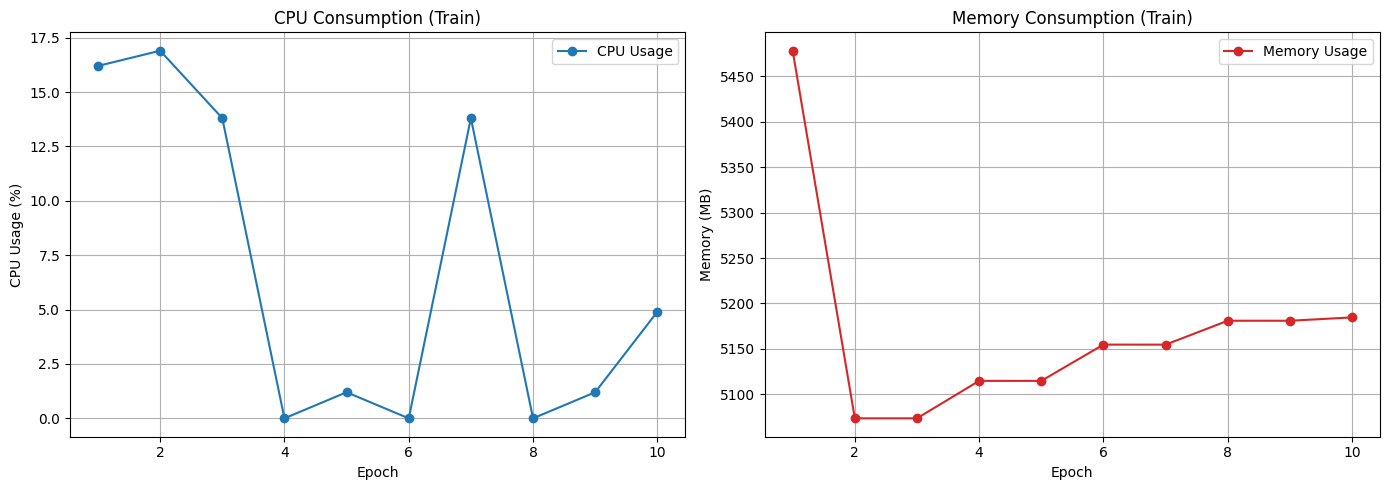

66305/66305 ━━━━━━━━━━━━━━━━━━━━ 64s 957us/step

====== General Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 16.52 seconds
Average CPU usage (Test): 6.43%
Average memory usage (Test): 5158.17 MB
Estimated energy consumption: 35088.14 Joules


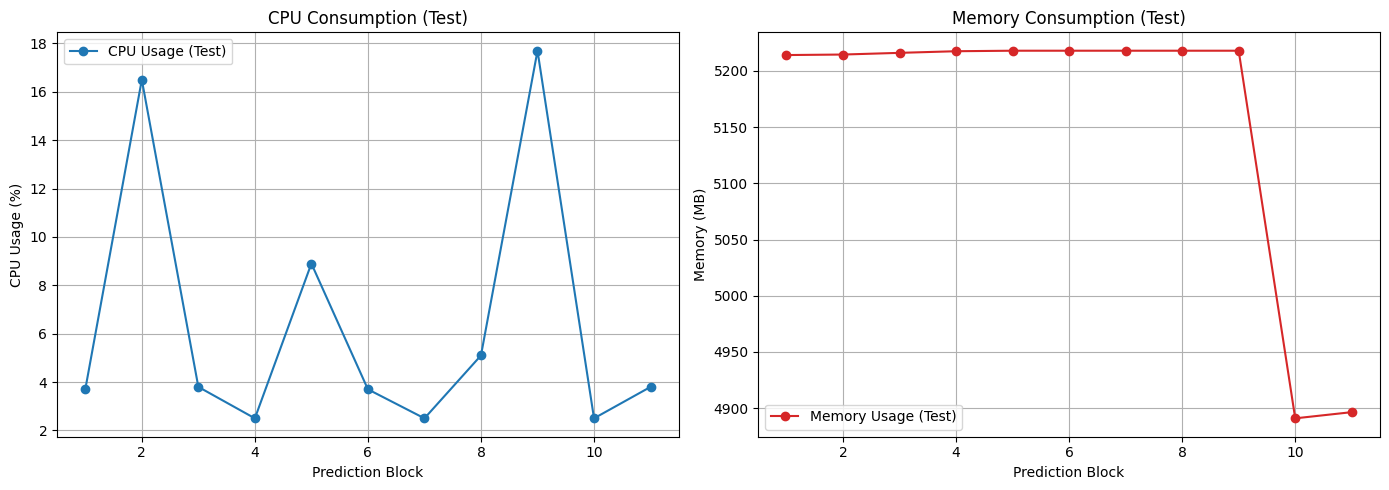

10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 905us/step

====== Zero-Day Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 4.19 seconds
Average CPU usage (Test): 6.03%
Average memory usage (Test): 5025.34 MB
Estimated energy consumption: 7339.23 Joules


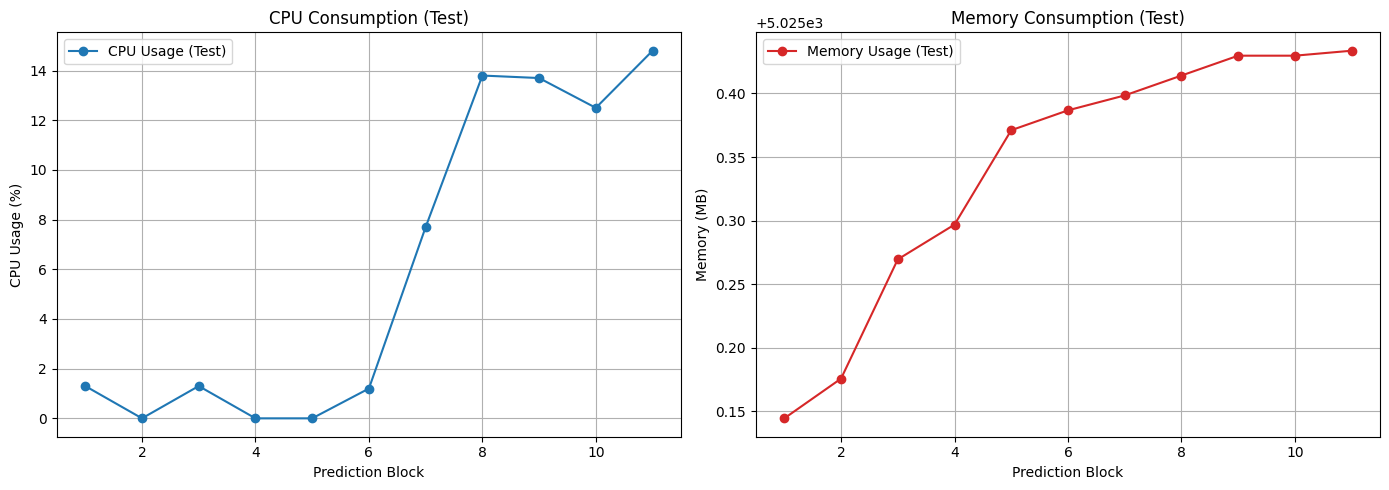

1430/1430 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 954us/step
STD reconstruction error: 142.7369128896639
ROC FULL=0.6005
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 969us/step
STD reconstruction error: 142.7369128896639
PR FULL=0.9127

====== Zero-Day: ssh ======
Total ssh in the original dataset: 14902
  Zero-days removed from training: 12009
  Zero-day in the original test: 2893
  Test full total: 344764

[Start of Training]

[Epoch 1 - Start] CPU: 0.00%, Memory: 5846.17 MB
[Epoch 1 - End] CPU: 13.80%, Memory: 5384.25 MB

[Epoch 2 - Start] CPU: 14.80%, Memory: 5384.29 MB
[Epoch 2 - End] CPU: 0.00%, Memory: 5419.32 MB

[Epoch 3 - Start] CPU: 0.00%, Memory: 5419.29 MB
[Epoch 3 - End] CPU: 1.20%, Memory: 5435.14 MB

[Epoch 4 - Start] CPU: 16.90%, Memory: 5435.12 MB
[Epoch 4 - End] CPU: 1.20%, Memory: 5466.04 MB

[Epoch 5 - Start] CPU: 1.30%, Memory: 5466.02 MB
[Epoch 5 - End] CPU: 0.00%, Memory: 5478.11 MB

[End of Training]
Total time: 194.89 seconds
Average CPU 

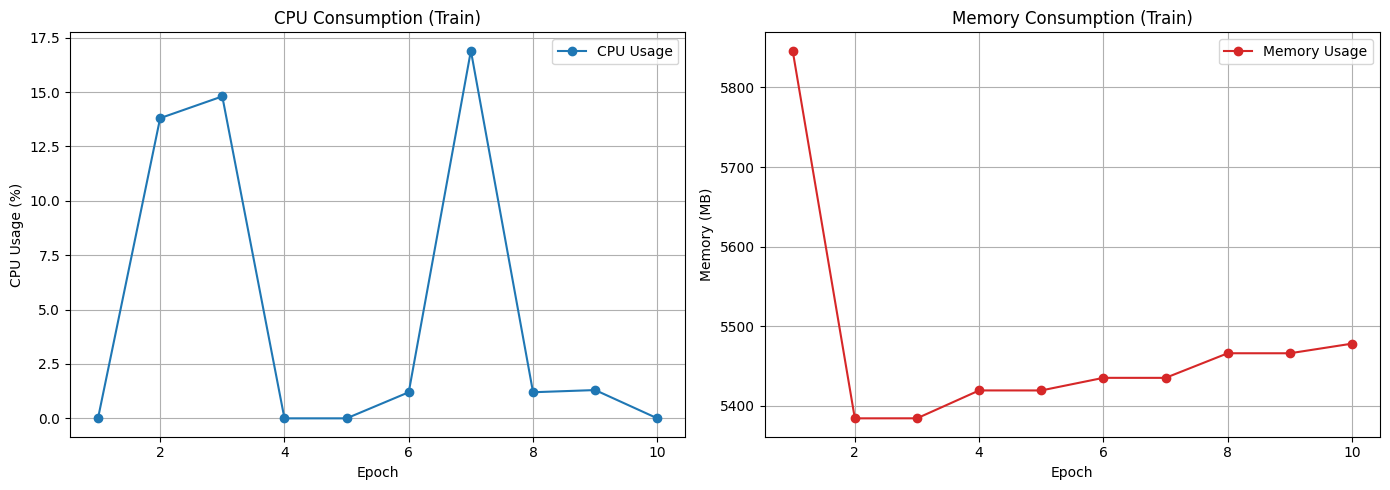

76908/76908 ━━━━━━━━━━━━━━━━━━━━ 80s 1ms/step

====== General Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 18.43 seconds
Average CPU usage (Test): 3.51%
Average memory usage (Test): 5547.46 MB
Estimated energy consumption: 6371.47 Joules


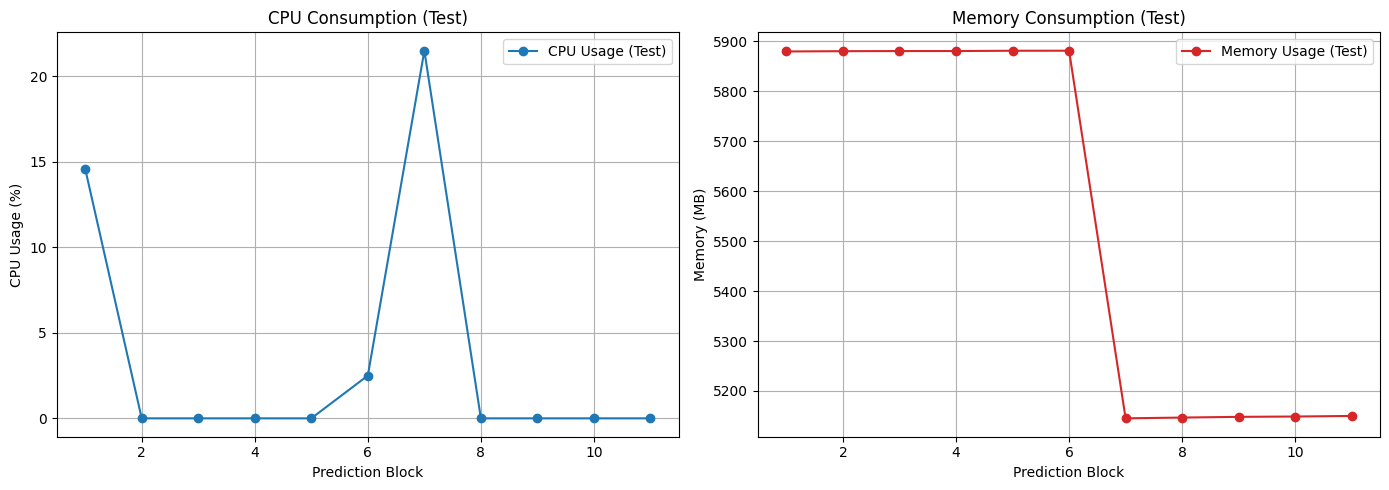

10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 949us/step

====== Zero-Day Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 2.31 seconds
Average CPU usage (Test): 1.69%
Average memory usage (Test): 5330.54 MB
Estimated energy consumption: 89.22 Joules


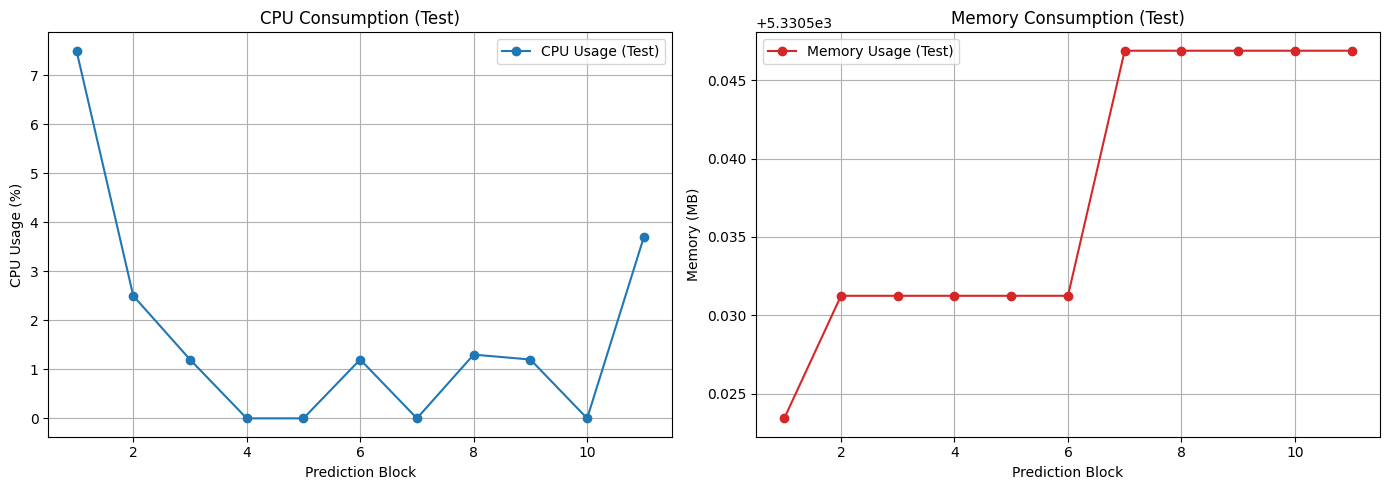

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 969us/step
STD reconstruction error: 165.42028499782947
ROC FULL=0.6001
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 9s 826us/step
STD reconstruction error: 165.42028499782947
PR FULL=0.9182

====== Zero-Day: ftp ======
Total ftp in the original dataset: 13664
  Zero-days removed from training: 10894
  Zero-day in the original test: 2770
  Test full total: 344764

[Start of Training]

[Epoch 1 - Start] CPU: 0.00%, Memory: 5937.79 MB
[Epoch 1 - End] CPU: 13.80%, Memory: 5460.94 MB

[Epoch 2 - Start] CPU: 14.10%, Memory: 5460.95 MB
[Epoch 2 - End] CPU: 14.10%, Memory: 5496.29 MB

[Epoch 3 - Start] CPU: 17.50%, Memory: 5496.26 MB
[Epoch 3 - End] CPU: 0.00%, Memory: 5520.37 MB

[Epoch 4 - Start] CPU: 2.50%, Memory: 5520.35 MB
[Epoch 4 - End] CPU: 14.60%, Memory: 5555.82 MB

[Epoch 5 - Start] CPU: 2.50%, Memory: 5555.80 MB
[Epoch 5 - End] CPU: 0.00%, Memory: 5606.48 MB

[End of Training]
Total time: 198.47 seconds
Average CPU u

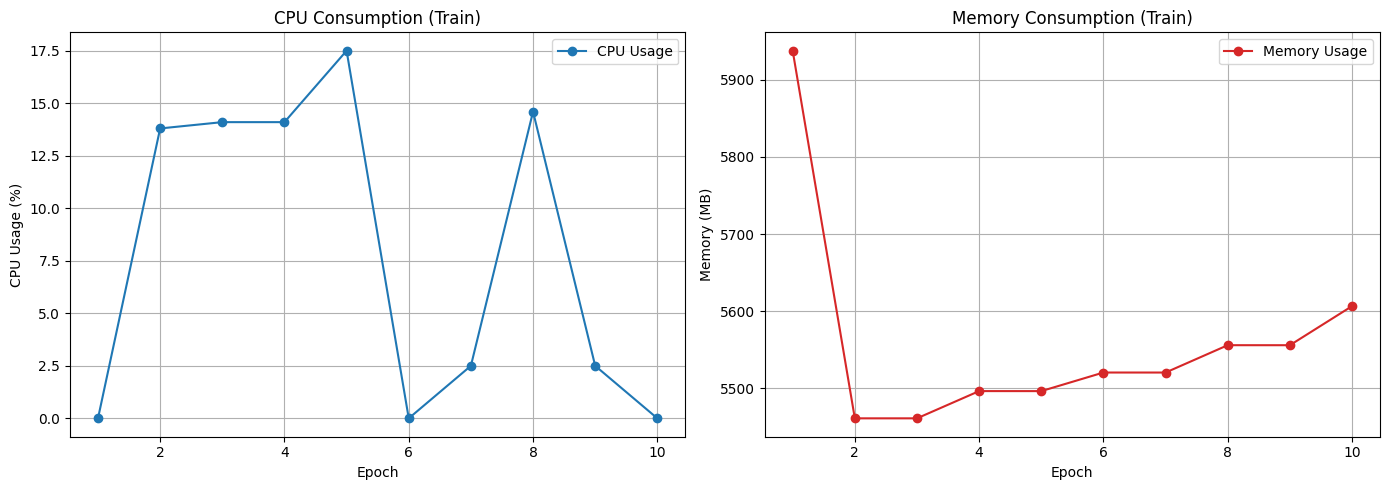

76977/76977 ━━━━━━━━━━━━━━━━━━━━ 73s 952us/step

====== General Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 16.15 seconds
Average CPU usage (Test): 1.69%
Average memory usage (Test): 5427.63 MB
Estimated energy consumption: 624.50 Joules


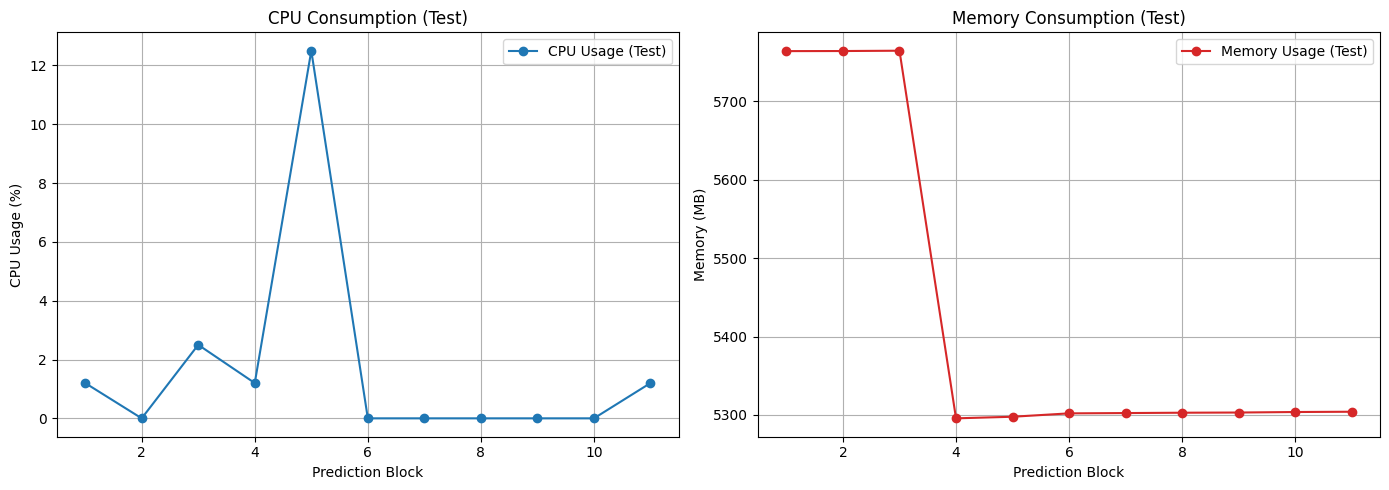

10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 945us/step

====== Zero-Day Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 2.05 seconds
Average CPU usage (Test): 0.87%
Average memory usage (Test): 5493.97 MB
Estimated energy consumption: 10.81 Joules


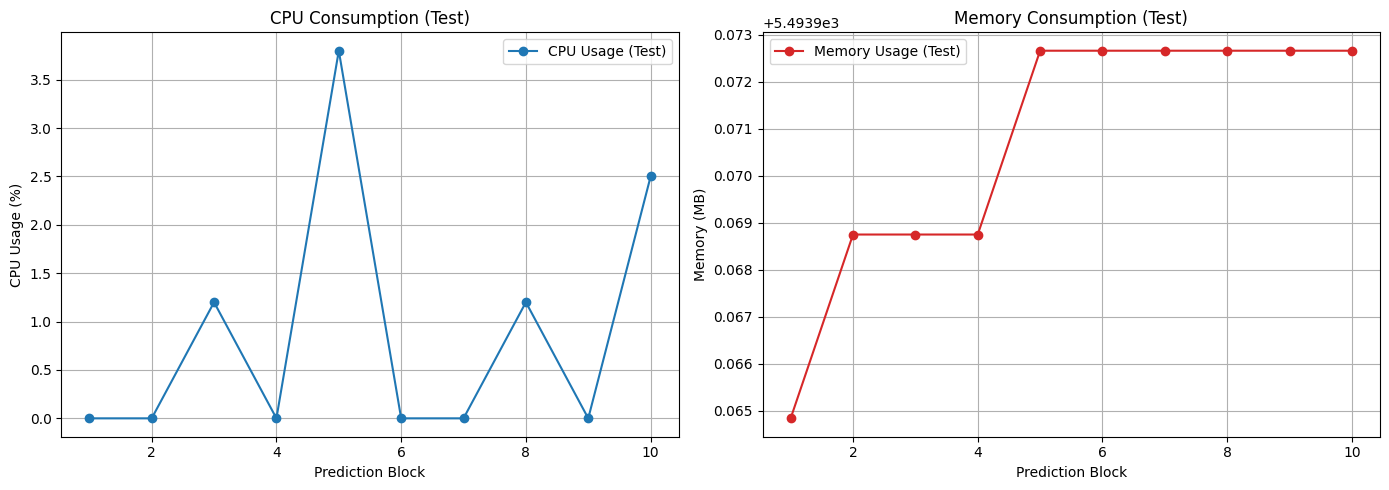

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 11s 973us/step
STD reconstruction error: 165.57614107761103
ROC FULL=0.5994
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 879us/step
STD reconstruction error: 165.57614107761103
PR FULL=0.9181

====== Zero-Day: portscan_tcp ======
Total portscan_tcp in the original dataset: 100000
  Zero-days removed from training: 80192
  Zero-day in the original test: 19808
  Test full total: 344764

[Start of Training]

[Epoch 1 - Start] CPU: 0.00%, Memory: 6108.72 MB
[Epoch 1 - End] CPU: 1.20%, Memory: 5544.71 MB

[Epoch 2 - Start] CPU: 1.20%, Memory: 5544.71 MB
[Epoch 2 - End] CPU: 0.00%, Memory: 5614.73 MB

[Epoch 3 - Start] CPU: 13.80%, Memory: 5614.71 MB
[Epoch 3 - End] CPU: 0.00%, Memory: 5643.39 MB

[Epoch 4 - Start] CPU: 3.70%, Memory: 5643.37 MB
[Epoch 4 - End] CPU: 0.00%, Memory: 5647.49 MB

[Epoch 5 - Start] CPU: 3.70%, Memory: 5647.47 MB
[Epoch 5 - End] CPU: 1.20%, Memory: 5665.42 MB

[End of Training]
Total time: 192.10 seco

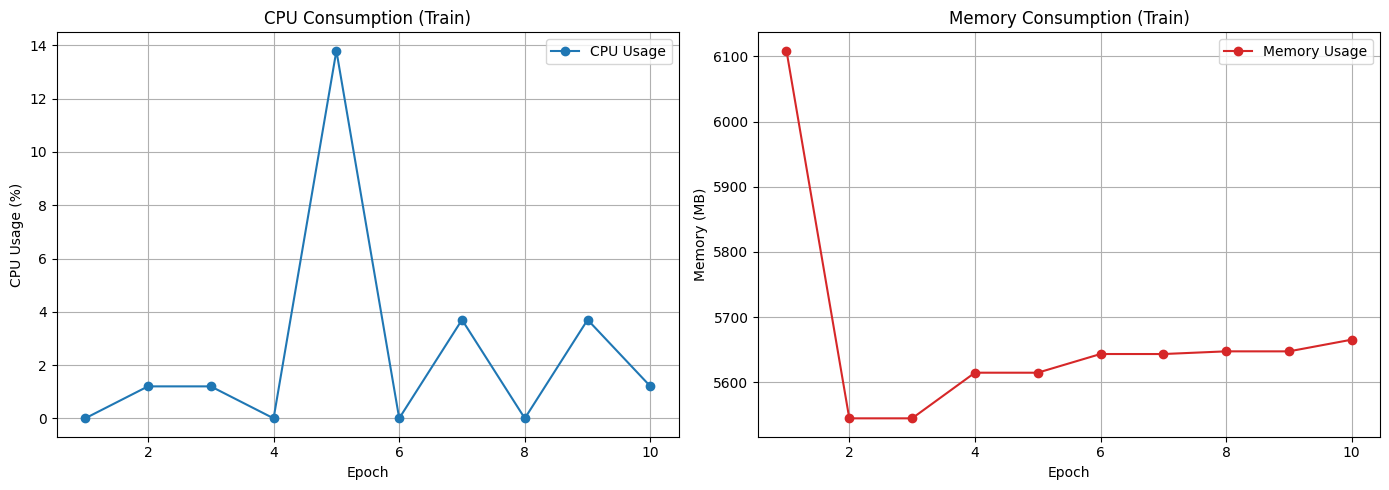

72646/72646 ━━━━━━━━━━━━━━━━━━━━ 72s 996us/step

====== General Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 16.33 seconds
Average CPU usage (Test): 3.24%
Average memory usage (Test): 5449.35 MB
Estimated energy consumption: 4428.50 Joules


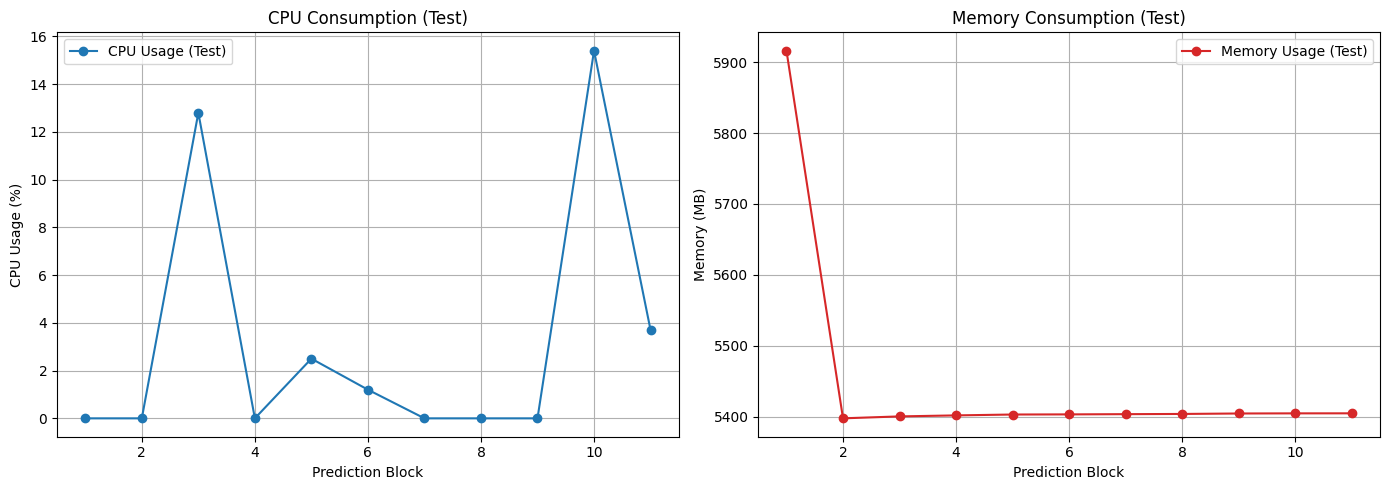

10774/10774 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step

====== Zero-Day Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 3.03 seconds
Average CPU usage (Test): 0.66%
Average memory usage (Test): 5627.32 MB
Estimated energy consumption: 7.09 Joules


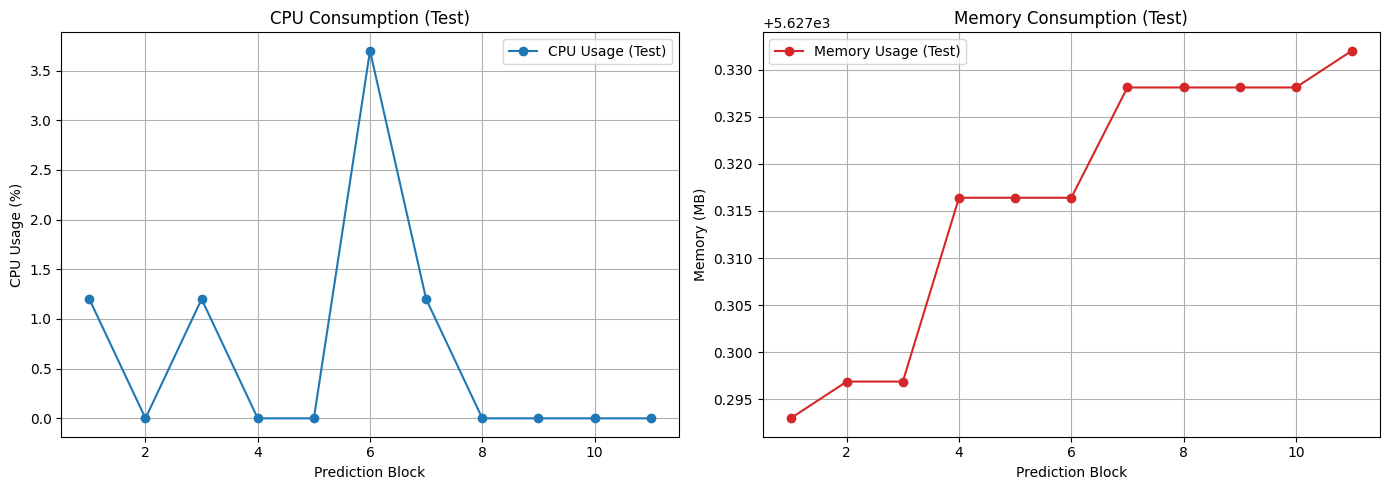

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 891us/step
STD reconstruction error: 156.2837800828441
ROC FULL=0.5977
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 11s 984us/step
STD reconstruction error: 156.2837800828441
PR FULL=0.9180

====== Zero-Day: os_fingerprinting ======
Total os_fingerprinting in the original dataset: 62957
  Zero-days removed from training: 50265
  Zero-day in the original test: 12692
  Test full total: 344764

[Start of Training]

[Epoch 1 - Start] CPU: 1.20%, Memory: 6355.29 MB
[Epoch 1 - End] CPU: 0.00%, Memory: 5799.34 MB

[Epoch 2 - Start] CPU: 1.30%, Memory: 5799.32 MB
[Epoch 2 - End] CPU: 0.00%, Memory: 5821.49 MB

[Epoch 3 - Start] CPU: 6.30%, Memory: 5821.47 MB
[Epoch 3 - End] CPU: 0.00%, Memory: 5822.52 MB

[Epoch 4 - Start] CPU: 15.20%, Memory: 5822.50 MB
[Epoch 4 - End] CPU: 0.00%, Memory: 5814.63 MB

[Epoch 5 - Start] CPU: 1.20%, Memory: 5814.61 MB
[Epoch 5 - End] CPU: 0.00%, Memory: 5816.99 MB

[End of Training]
Total time: 19

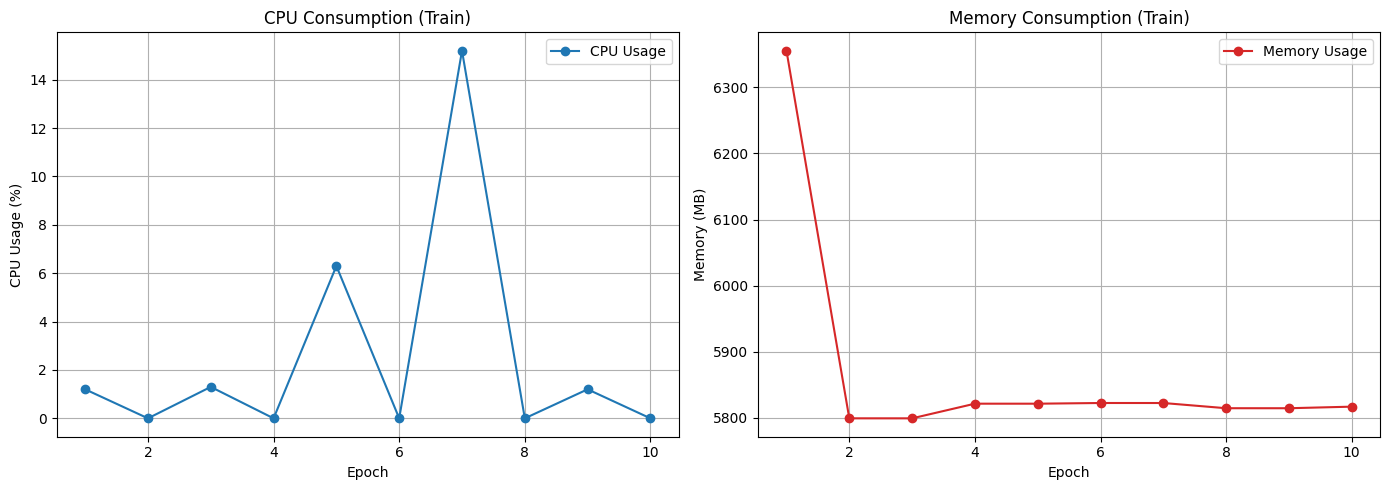

74517/74517 ━━━━━━━━━━━━━━━━━━━━ 87s 1ms/step

====== General Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 17.12 seconds
Average CPU usage (Test): 2.16%
Average memory usage (Test): 5767.31 MB
Estimated energy consumption: 1387.53 Joules


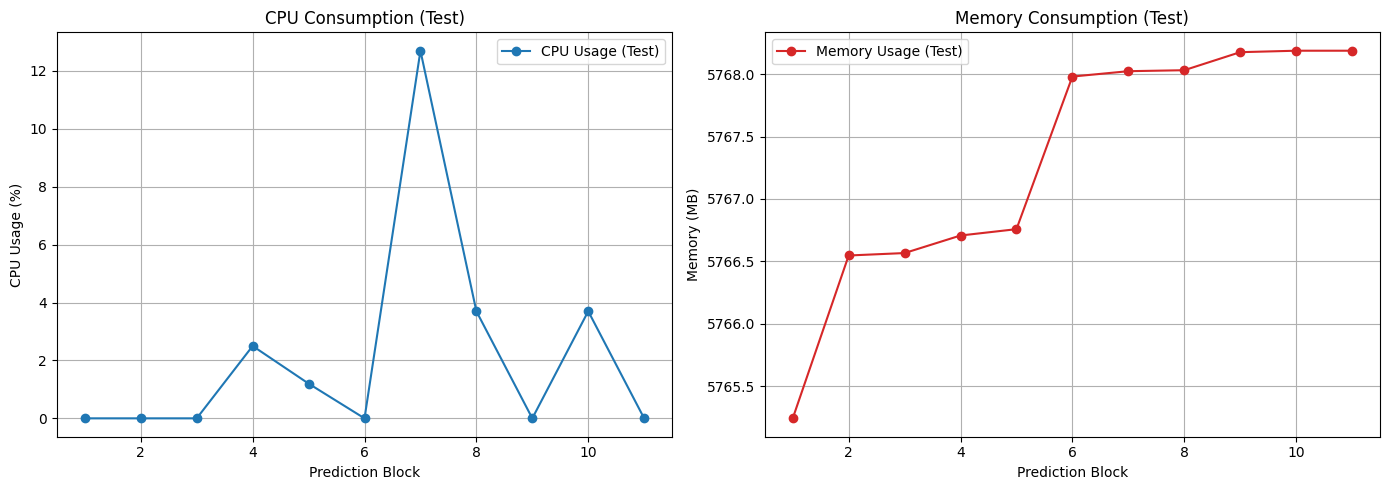

10774/10774 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step

====== Zero-Day Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 2.75 seconds
Average CPU usage (Test): 0.56%
Average memory usage (Test): 5889.46 MB
Estimated energy consumption: 3.93 Joules


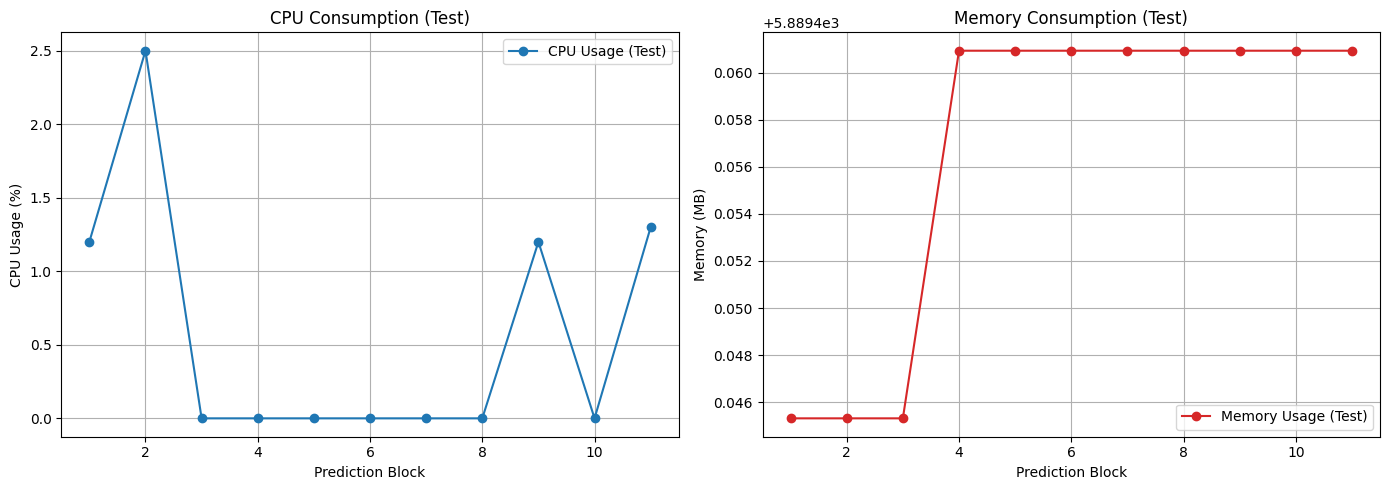

397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step
STD reconstruction error: 160.3045137807723
ROC FULL=0.6057
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 11s 977us/step
STD reconstruction error: 160.3045137807723
PR FULL=0.9185

====== Zero-Day: portscan_udp ======
Total portscan_udp in the original dataset: 20336
  Zero-days removed from training: 16281
  Zero-day in the original test: 4055
  Test full total: 344764

[Start of Training]

[Epoch 1 - Start] CPU: 18.80%, Memory: 5687.95 MB
[Epoch 1 - End] CPU: 0.00%, Memory: 5826.91 MB

[Epoch 2 - Start] CPU: 1.20%, Memory: 5826.88 MB
[Epoch 2 - End] CPU: 1.30%, Memory: 5901.13 MB

[Epoch 3 - Start] CPU: 2.50%, Memory: 5901.11 MB
[Epoch 3 - End] CPU: 1.30%, Memory: 5901.93 MB

[Epoch 4 - Start] CPU: 18.50%, Memory: 5901.91 MB
[Epoch 4 - End] CPU: 3.70%, Memory: 5905.91 MB

[Epoch 5 - Start] CPU: 1.30%, Memory: 5905.89 MB
[Epoch 5 - End] CPU: 2.40%, Memory: 5908.48 MB

[End of Training]
Total time: 252.99 seconds

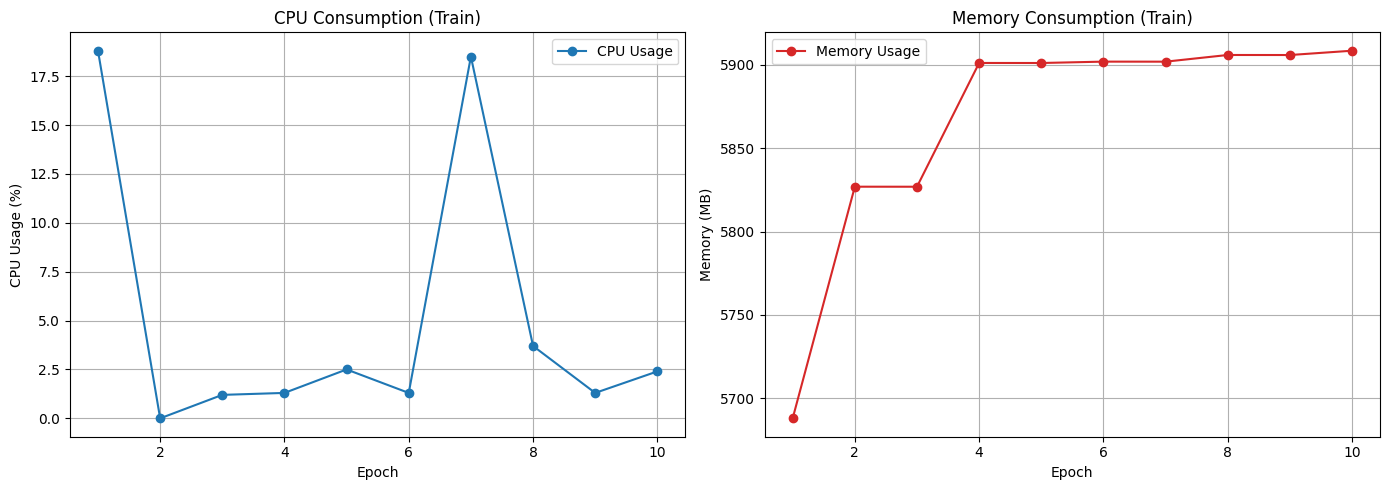

76641/76641 ━━━━━━━━━━━━━━━━━━━━ 75s 974us/step

====== General Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 16.80 seconds
Average CPU usage (Test): 2.85%
Average memory usage (Test): 6103.65 MB
Estimated energy consumption: 3126.37 Joules


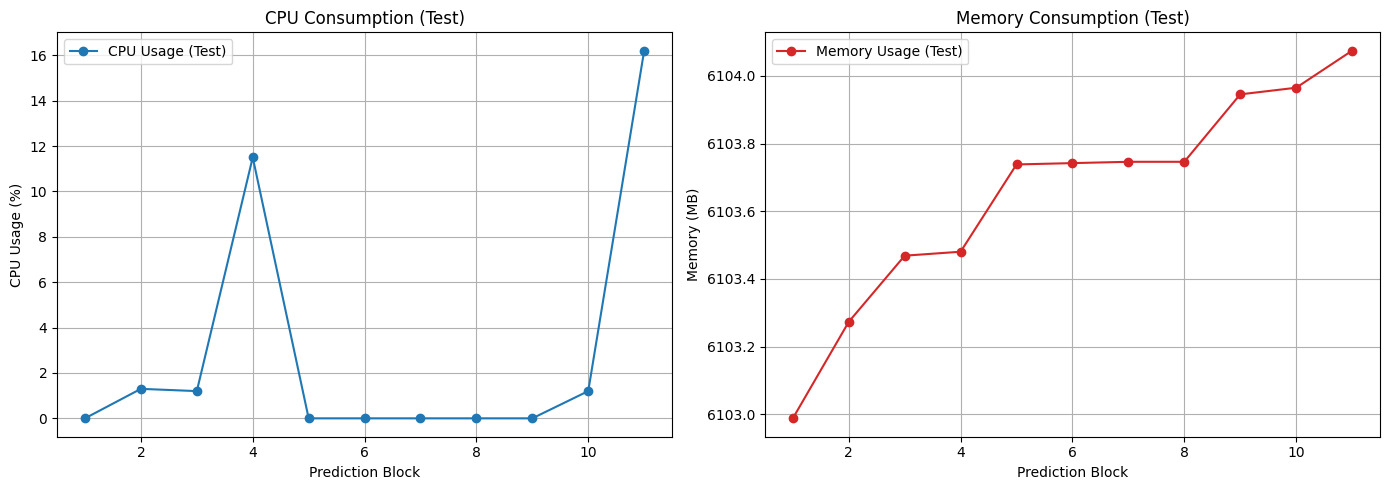

10774/10774 ━━━━━━━━━━━━━━━━━━━━ 9s 878us/step

====== Zero-Day Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 2.35 seconds
Average CPU usage (Test): 0.68%
Average memory usage (Test): 6115.32 MB
Estimated energy consumption: 5.96 Joules


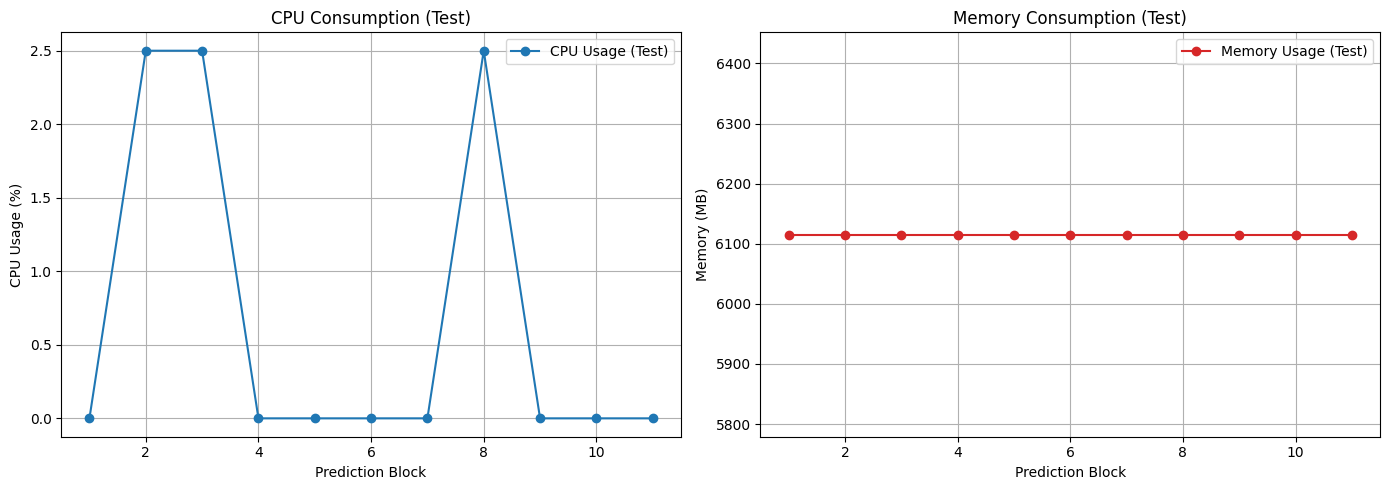

127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step
STD reconstruction error: 164.8562412795428
ROC FULL=0.6029
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 903us/step
STD reconstruction error: 164.8562412795428
PR FULL=0.9190

====== Zero-Day: http_flood ======
Total http_flood in the original dataset: 254314
  Zero-days removed from training: 203559
  Zero-day in the original test: 50755
  Test full total: 344764

[Start of Training]

[Epoch 1 - Start] CPU: 0.00%, Memory: 6332.51 MB
[Epoch 1 - End] CPU: 1.20%, Memory: 5687.87 MB

[Epoch 2 - Start] CPU: 5.10%, Memory: 5687.85 MB
[Epoch 2 - End] CPU: 1.20%, Memory: 5730.59 MB

[Epoch 3 - Start] CPU: 2.50%, Memory: 5730.56 MB
[Epoch 3 - End] CPU: 0.00%, Memory: 5745.12 MB

[Epoch 4 - Start] CPU: 1.30%, Memory: 5745.10 MB
[Epoch 4 - End] CPU: 0.00%, Memory: 5749.19 MB

[Epoch 5 - Start] CPU: 1.30%, Memory: 5749.16 MB
[Epoch 5 - End] CPU: 1.20%, Memory: 5769.29 MB

[End of Training]
Total time: 191.19 seconds
Av

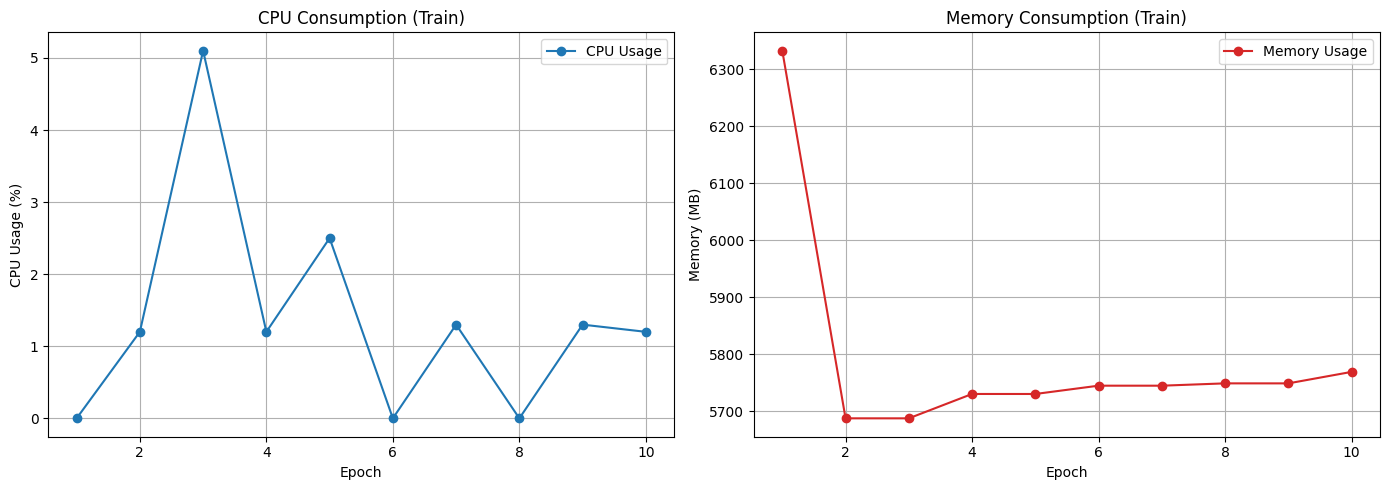

64936/64936 ━━━━━━━━━━━━━━━━━━━━ 69s 1ms/step

====== General Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 21.26 seconds
Average CPU usage (Test): 1.82%
Average memory usage (Test): 5796.71 MB
Estimated energy consumption: 1022.45 Joules


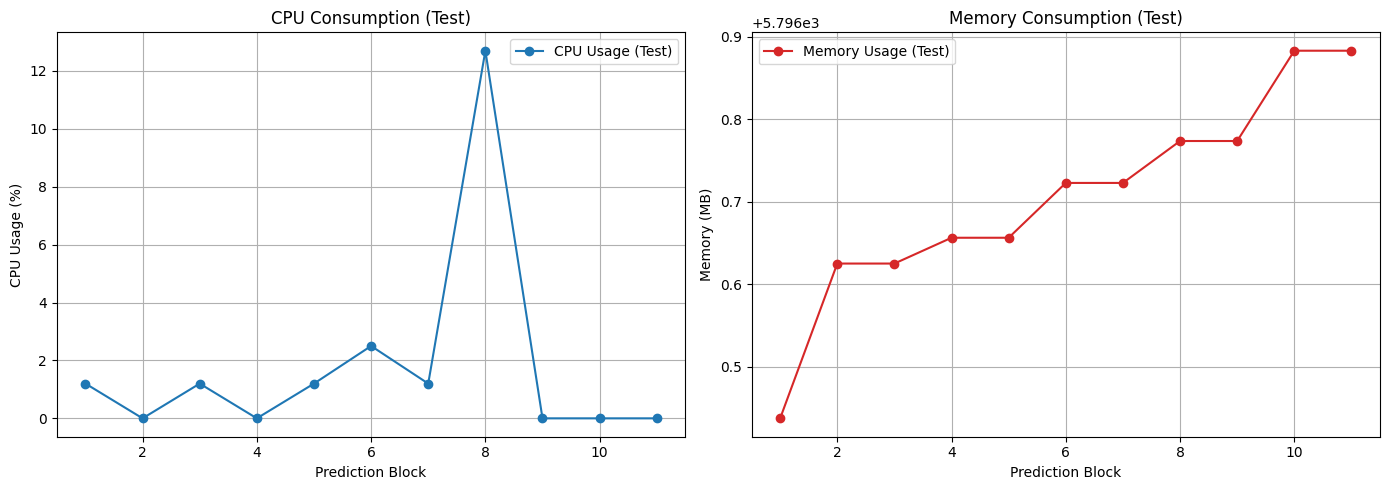

10774/10774 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step

====== Zero-Day Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 5.54 seconds
Average CPU usage (Test): 0.44%
Average memory usage (Test): 5852.32 MB
Estimated energy consumption: 3.68 Joules


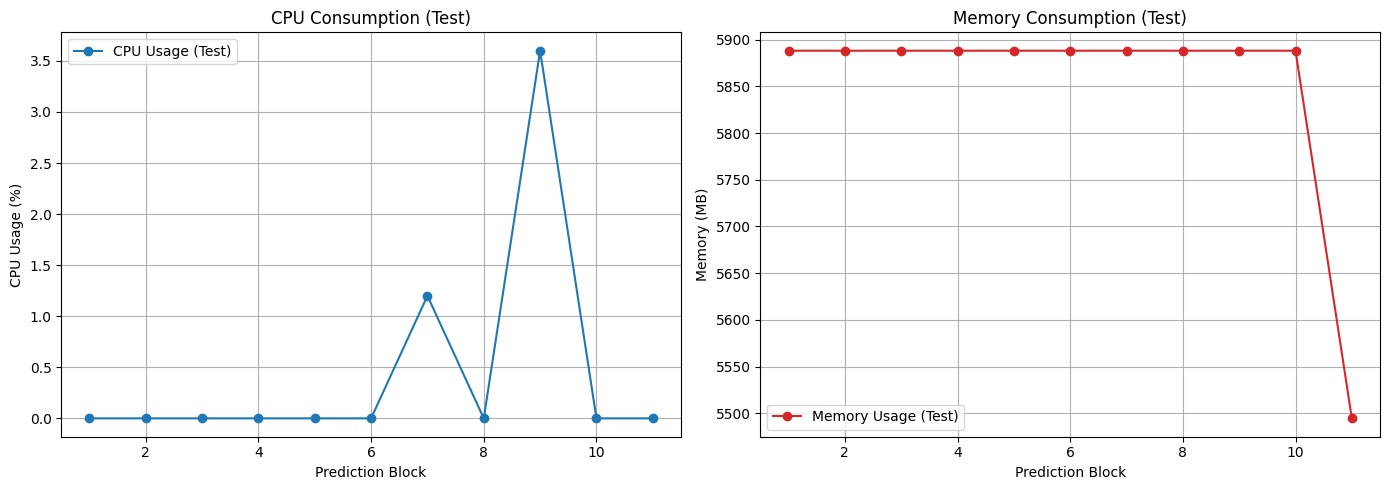

1587/1587 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step
STD reconstruction error: 139.72176670730212
ROC FULL=0.4614
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step
STD reconstruction error: 139.72176670730212
PR FULL=0.9079

====== Zero-Day: dir_bruteforce ======
Total dir_bruteforce in the original dataset: 28566
  Zero-days removed from training: 22843
  Zero-day in the original test: 5723
  Test full total: 344764

[Start of Training]

[Epoch 1 - Start] CPU: 15.20%, Memory: 6518.23 MB
[Epoch 1 - End] CPU: 0.00%, Memory: 6010.92 MB

[Epoch 2 - Start] CPU: 6.30%, Memory: 6010.90 MB
[Epoch 2 - End] CPU: 16.50%, Memory: 6044.11 MB

[Epoch 3 - Start] CPU: 2.50%, Memory: 6046.20 MB
[Epoch 3 - End] CPU: 13.70%, Memory: 6050.89 MB

[Epoch 4 - Start] CPU: 1.30%, Memory: 6050.86 MB
[Epoch 4 - End] CPU: 2.50%, Memory: 6068.56 MB

[Epoch 5 - Start] CPU: 2.50%, Memory: 6068.55 MB
[Epoch 5 - End] CPU: 0.00%, Memory: 6069.16 MB

[End of Training]
Total time: 248.75 

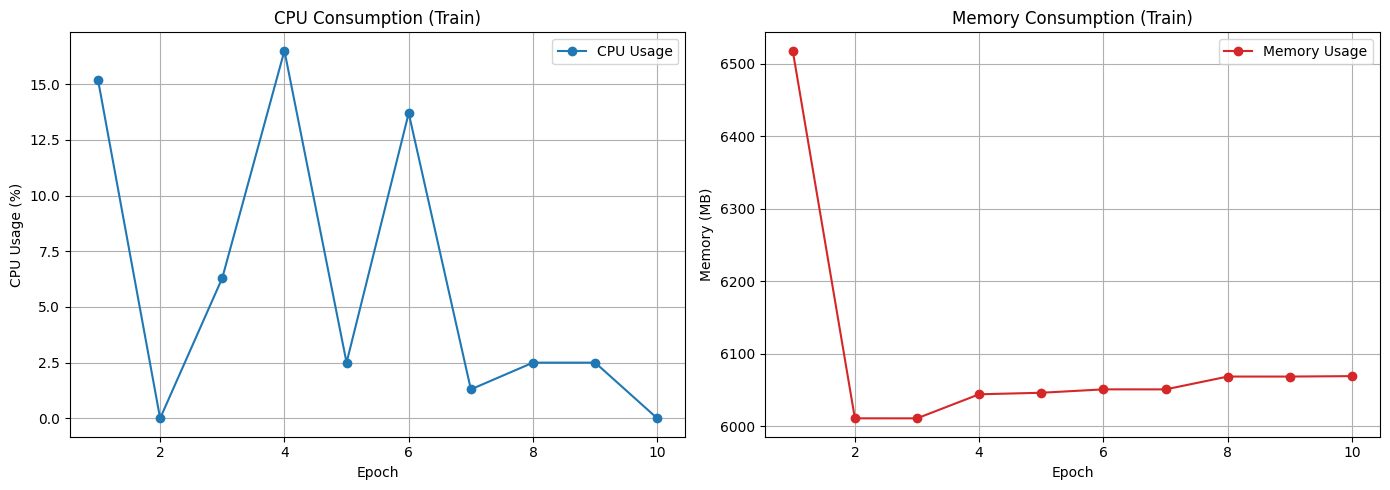

76231/76231 ━━━━━━━━━━━━━━━━━━━━ 81s 1ms/step

====== General Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 17.93 seconds
Average CPU usage (Test): 2.60%
Average memory usage (Test): 6157.40 MB
Estimated energy consumption: 2520.59 Joules


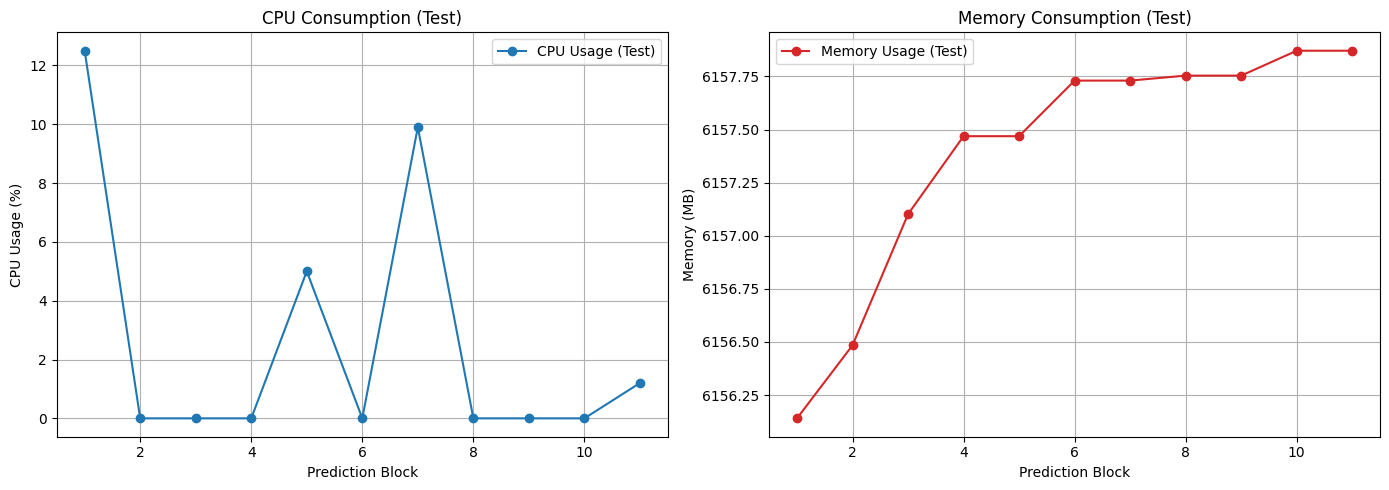

10774/10774 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step

====== Zero-Day Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 2.55 seconds
Average CPU usage (Test): 0.78%
Average memory usage (Test): 6045.26 MB
Estimated energy consumption: 9.75 Joules


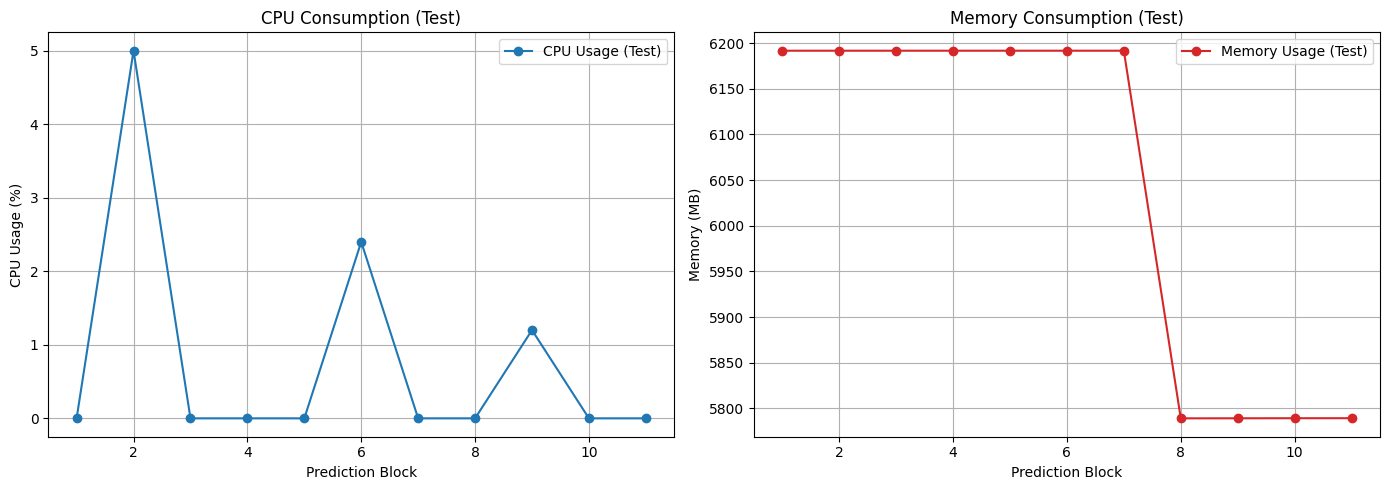

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 11s 985us/step
STD reconstruction error: 163.9630305724616
ROC FULL=0.5918
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step
STD reconstruction error: 163.9630305724616
PR FULL=0.9208

====== Zero-Day: xss ======
Total xss in the original dataset: 3661
  Zero-days removed from training: 2893
  Zero-day in the original test: 768
  Test full total: 344764

[Start of Training]

[Epoch 1 - Start] CPU: 15.20%, Memory: 6555.49 MB
[Epoch 1 - End] CPU: 1.30%, Memory: 6155.61 MB

[Epoch 2 - Start] CPU: 15.20%, Memory: 6155.58 MB
[Epoch 2 - End] CPU: 0.00%, Memory: 6208.19 MB

[Epoch 3 - Start] CPU: 12.70%, Memory: 6208.16 MB
[Epoch 3 - End] CPU: 19.80%, Memory: 6216.98 MB

[Epoch 4 - Start] CPU: 17.30%, Memory: 6216.96 MB
[Epoch 4 - End] CPU: 14.80%, Memory: 6221.46 MB

[Epoch 5 - Start] CPU: 19.00%, Memory: 6221.43 MB
[Epoch 5 - End] CPU: 2.50%, Memory: 6222.81 MB

[End of Training]
Total time: 239.63 seconds
Average CPU usa

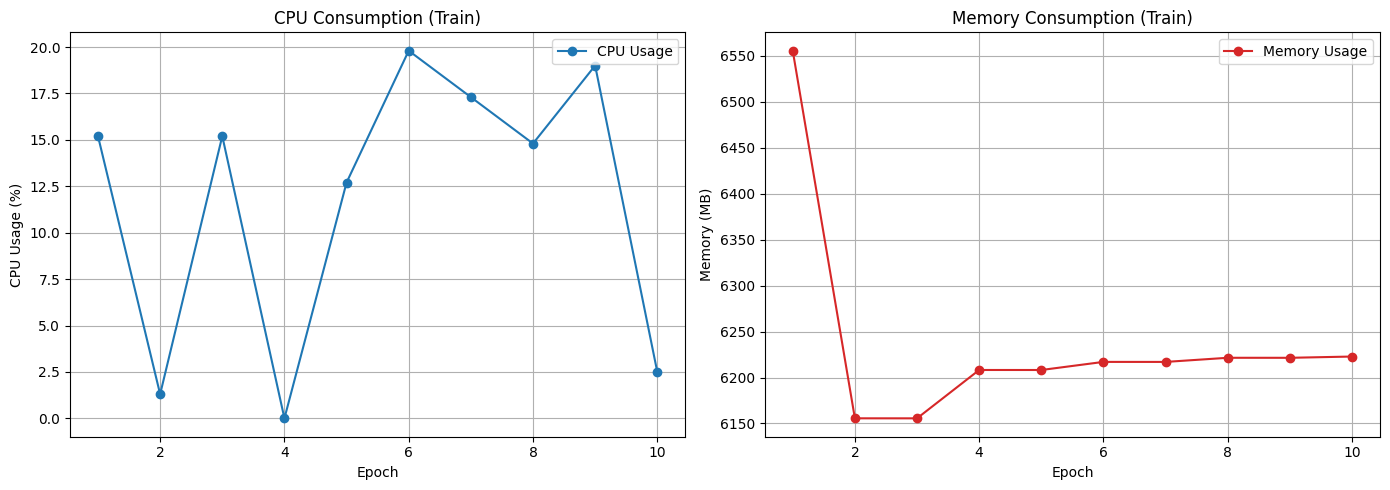

77477/77477 ━━━━━━━━━━━━━━━━━━━━ 90s 1ms/step

====== General Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 14.85 seconds
Average CPU usage (Test): 1.84%
Average memory usage (Test): 6368.31 MB
Estimated energy consumption: 735.73 Joules


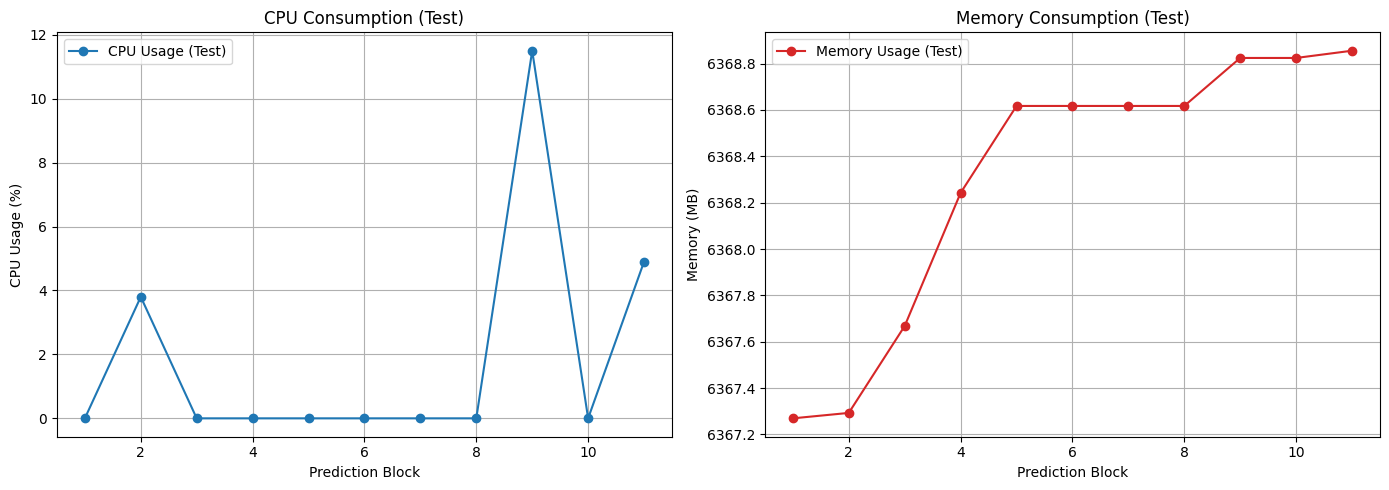

10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 894us/step

====== Zero-Day Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 2.18 seconds
Average CPU usage (Test): 0.90%
Average memory usage (Test): 6073.52 MB
Estimated energy consumption: 12.72 Joules


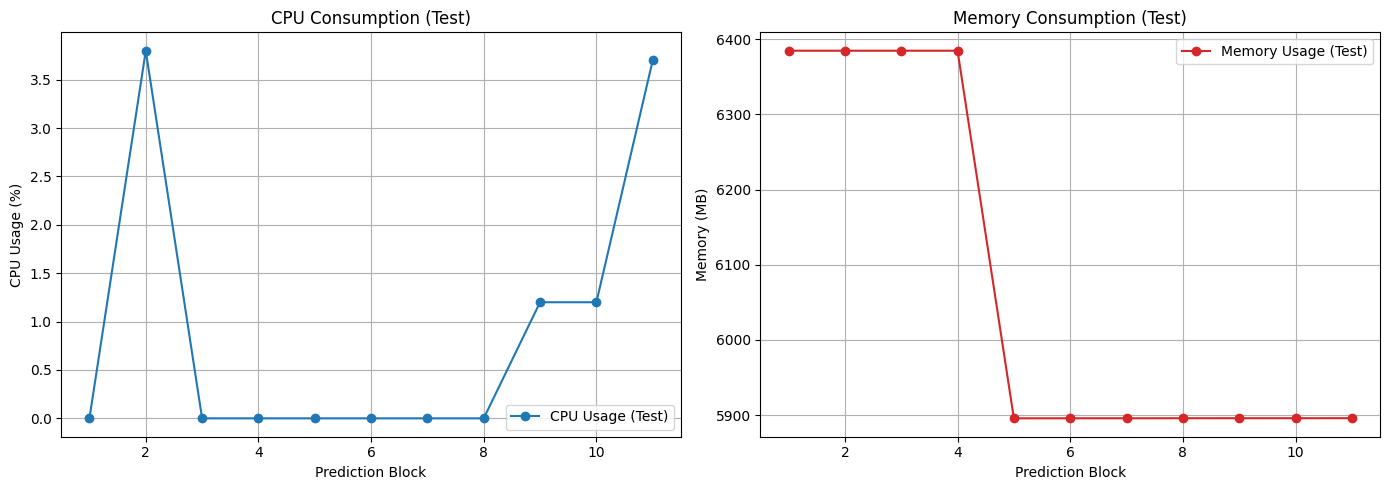

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 918us/step
STD reconstruction error: 166.6504805696881
ROC FULL=0.5995
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 9s 850us/step
STD reconstruction error: 166.6504805696881
PR FULL=0.9184

====== Zero-Day: sql_injection ======
Total sql_injection in the original dataset: 1763
  Zero-days removed from training: 1427
  Zero-day in the original test: 336
  Test full total: 344764

[Start of Training]

[Epoch 1 - Start] CPU: 12.70%, Memory: 6704.86 MB
[Epoch 1 - End] CPU: 1.20%, Memory: 6208.35 MB

[Epoch 2 - Start] CPU: 2.50%, Memory: 6209.75 MB
[Epoch 2 - End] CPU: 13.60%, Memory: 6271.71 MB

[Epoch 3 - Start] CPU: 2.50%, Memory: 6276.38 MB
[Epoch 3 - End] CPU: 0.00%, Memory: 6291.59 MB

[Epoch 4 - Start] CPU: 3.70%, Memory: 6291.56 MB
[Epoch 4 - End] CPU: 0.00%, Memory: 6311.08 MB

[Epoch 5 - Start] CPU: 3.70%, Memory: 6311.05 MB
[Epoch 5 - End] CPU: 0.00%, Memory: 6333.88 MB

[End of Training]
Total time: 198.93 seconds


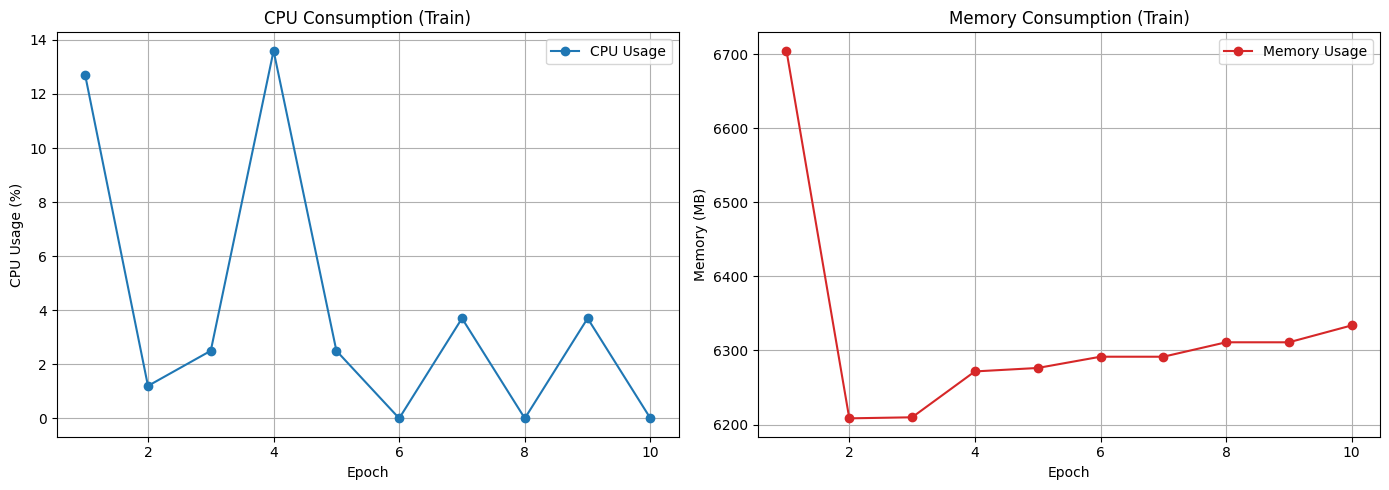

77569/77569 ━━━━━━━━━━━━━━━━━━━━ 69s 885us/step

====== General Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 15.83 seconds
Average CPU usage (Test): 1.59%
Average memory usage (Test): 6479.28 MB
Estimated energy consumption: 509.96 Joules


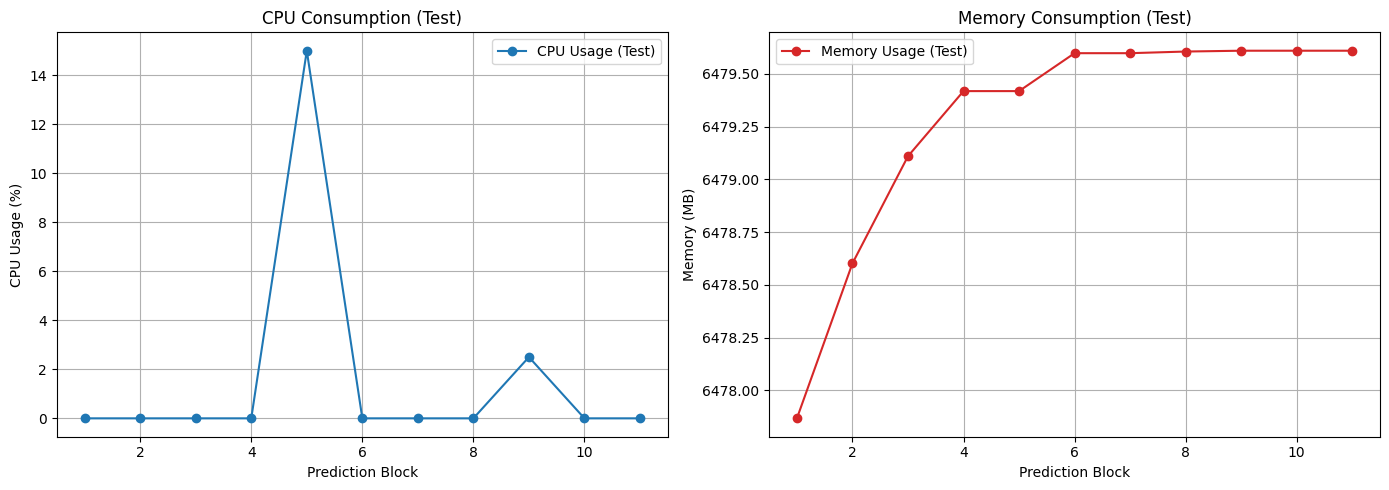

10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 915us/step

====== Zero-Day Resource Allocation ======

[Start of Prediction/Test]

[End of Prediction/Test]
Total time: 2.22 seconds
Average CPU usage (Test): 1.01%
Average memory usage (Test): 6089.24 MB
Estimated energy consumption: 18.28 Joules


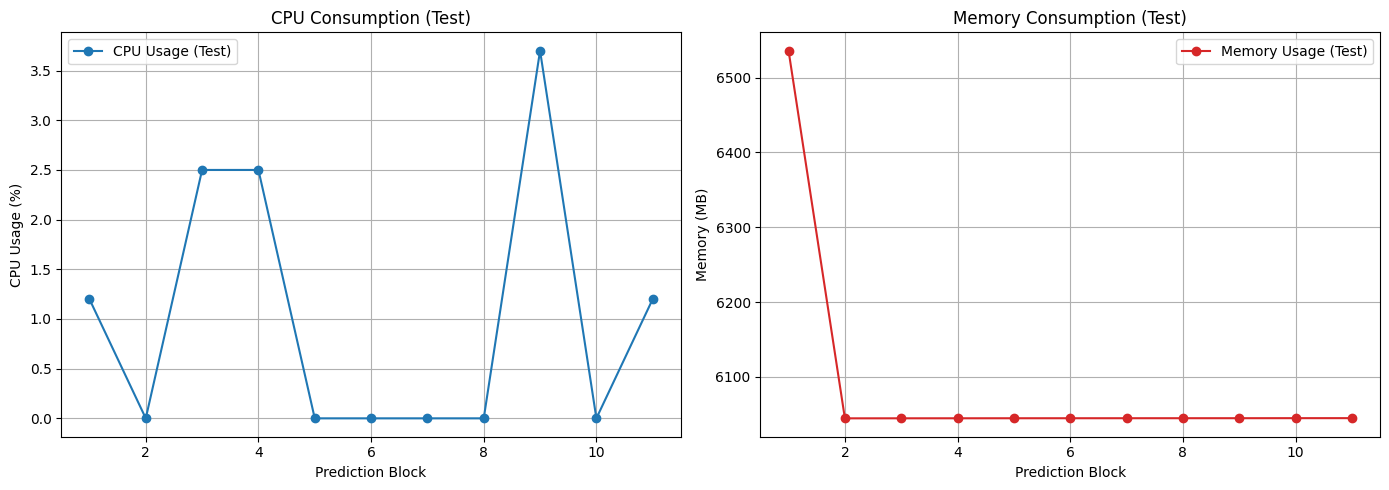

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 943us/step
STD reconstruction error: 166.84979462848662
ROC FULL=0.5994
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 10s 901us/step
STD reconstruction error: 166.84979462848662
PR FULL=0.9184


In [ ]:
# ===== IMPORTS =====
import pandas as pd
import numpy as np
import time
import psutil
import gc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import os

# Configuração das features e rótulos
features = [
    'src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes', 'missed_bytes',
    'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'ip_proto',
    'http_trans_depth', 'files_total_bytes', 'is_GET_mthd',
    'http_status_error', 'is_file_transfered', 'attack_type'
]

X = encoded[features]
y = encoded['Label']  # Coluna de rótulos

# Dividir antes de escolher zero-days
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Guardar Attack Type para separar os zero-days
X_train['attack_type'] = encoded.loc[X_train.index, 'attack_type']
X_test['attack_type'] = encoded.loc[X_test.index, 'attack_type']

# ===== CONFIGURAÇÕES =====
zero_day_attacks = ['tcp_ack', 'syn', 'icmp', 'slowloris', 'udp', 'ssh', 'ftp', 'portscan_tcp', 'os_fingerprinting', 'portscan_udp', 'http_flood', 'dir_bruteforce', 'xss', 'sql_injection']
#zero_day_attacks = ['tcp_ack']
smote = SMOTE(random_state=42)
scaler = StandardScaler()
label_encoder = LabelEncoder()

model_name = "Autoencoder"
roc_full_curves = []
pr_full_curves = []

train_csv = []
resultados_zero_day = []

# ===== LOOP PRINCIPAL =====
for ataque_zero_day in zero_day_attacks:
    print(f"\n====== Zero-Day: {ataque_zero_day} ======")

    # --- Contagem no dataset original ---
    total_in_original = (X['attack_type'] == ataque_zero_day).sum()
    print(f"Total {ataque_zero_day} in the original dataset: {total_in_original}")
    mask_train = X_train['attack_type'] != ataque_zero_day
    train_removed = (~mask_train).sum()

    X_train_clean = X_train.loc[mask_train].drop(columns=['attack_type']).copy()
    y_train_clean = y_train.loc[mask_train].copy()
    print(f"  Zero-days removed from training: {train_removed}")

    mask_test_zero = X_test['attack_type'] == ataque_zero_day
    X_test_zero_day = X_test.loc[mask_test_zero].drop(columns=['attack_type']).copy()
    y_test_zero_day = y_test.loc[mask_test_zero].copy()
    print(f"  Zero-day in the original test: {mask_test_zero.sum()}")

    X_test_full = X_test.drop(columns=['attack_type']).copy()
    y_test_full = y_test.copy()
    print(f"  Test full total: {len(X_test_full)}")

    # --- Balanceamento com SMOTE ---
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_clean, y_train_clean)

    # --- Normalização ---
    X_train_scaled = scaler.fit_transform(X_train_balanced)
    X_test_full_scaled = scaler.transform(X_test_full)
    X_test_zero_day_scaled = scaler.transform(X_test_zero_day)

    # --- Construção do Autoencoder ---
    input_dim = X_train_scaled.shape[1]
    encoding_dim = 32  # latente

    input_layer = Input(shape=(input_dim,))
    encoded = Dense(64, activation="relu")(input_layer)
    encoded = Dense(encoding_dim, activation="relu")(encoded)
    decoded = Dense(64, activation="relu")(encoded)
    output_layer = Dense(input_dim, activation="sigmoid")(decoded)

    autoencoder = Model(input_layer, output_layer)
    autoencoder.compile(optimizer="adam", loss="mse")

    # --- Treinamento com monitoramento ---
    history = autoencoder.fit(
        X_train_scaled, X_train_scaled,
        epochs=20,
        batch_size=128,
        validation_split=0.2,
        callbacks=[early_stopping, reduce_lr, resource_monitor],
        verbose=0
    )

    # ================================================
    # TREINO COM MONITORAMENTO
    # ================================================
    train_csv.append({
        "attack": ataque_zero_day,
        "total_time_train": resource_monitor.total_time,
        "avg_cpu_train": resource_monitor.avg_cpu,
        "avg_mem_train": resource_monitor.avg_mem,
        "energy_train": resource_monitor.energia,
    })

    # =============================
    # Definir threshold (a partir do treino benigno)
    # =============================
    recon_train = autoencoder.predict(X_train_scaled)
    train_errors = np.mean(np.power(X_train_scaled - recon_train, 2), axis=1)
    threshold = np.percentile(train_errors, 70)

    # =============================
    # Função para calcular métricas
    # =============================
    def avaliar(autoencoder, X, y_true, threshold):
        recon = autoencoder.predict(X)
        errors = np.mean(np.power(X - recon, 2), axis=1)
        y_pred = (errors > threshold).astype(int)
        return {
            "F1": f1_score(y_true, y_pred, zero_division=1),
            "Precision": precision_score(y_true, y_pred, zero_division=1),
            "Recall": recall_score(y_true, y_pred, zero_division=1),
            "Accuracy": accuracy_score(y_true, y_pred)
        }

    # =============================
    # Codificação dos rótulos
    # =============================
    y_test_full_encoded = y_test_full
    y_test_zero_day_encoded = y_test_zero_day

    y_test_full_encoded = y_test_full
    y_test_zero_day_encoded = y_test_zero_day

    # =============================
    # TESTE GERAL COM MONITORAMENTO
    # =============================
    print('\n====== General Resource Allocation ======')
    metrics_test_full = monitor_test_prediction(autoencoder, X_test_full_scaled)
    result_full = avaliar(autoencoder, X_test_full_scaled, y_test_full_encoded, threshold)

    # =============================
    # TESTE ZERO-DAY COM MONITORAMENTO
    # =============================
    print('\n====== Zero-Day Resource Allocation ======')
    metrics_zero_day = monitor_test_prediction(autoencoder, X_test_zero_day_scaled)
    result_zero = avaliar(autoencoder, X_test_zero_day_scaled, y_test_zero_day_encoded, threshold)

    # =============================
    # Salvar resultados
    # =============================
    resultados_zero_day.append({
    'Attack Zero-Day': ataque_zero_day,

    'Accuracy': result_full['Accuracy'],
    'F1': result_full['F1'],
    'Precision': result_full['Precision'],
    'Recall': result_full['Recall'],
    'Time': metrics_test_full['total_time'],
    'CPU': metrics_test_full['avg_cpu'],
    'Memory': metrics_test_full['avg_mem'],
    'Energy': metrics_test_full['energia'],

    'ZD - Accuracy': result_zero['Accuracy'],
    'ZD - F1': result_zero['F1'],
    'ZD - Precision': result_zero['Precision'],
    'ZD - Recall': result_zero['Recall'],
    'ZD - Time': metrics_zero_day['total_time'],
    'ZD - CPU': metrics_zero_day['avg_cpu'],
    'ZD - Memory': metrics_zero_day['avg_mem'],
    'ZD - Energy': metrics_zero_day['energia'],
  })
    # =============================
    # CURVA ROC (AUTOENCODER) - TESTE FULL
    # =============================

    # Predição
    X_pred = autoencoder.predict(X_test_full_scaled)

    # Erro por amostra
    reconstruction_error = np.mean(np.square(X_test_full_scaled - X_pred), axis=1)

    # Verificação de valores constantes (debug)
    print("STD reconstruction error:", np.std(reconstruction_error))

    # Score contínuo
    probs_full = reconstruction_error

    # Geração da ROC
    fpr_full, tpr_full, _ = roc_curve(y_test_full_encoded, probs_full)
    roc_auc_full = auc(fpr_full, tpr_full)

    roc_full_curves.append((fpr_full, tpr_full, roc_auc_full, ataque_zero_day))

    print(f"ROC FULL={roc_auc_full:.4f}")

    # =============================
    # PR CURVE (AUTOENCODER) - TESTE FULL
    # =============================

    # Predição
    X_pred = autoencoder.predict(X_test_full_scaled)

    # Erro por amostra
    reconstruction_error = np.mean(np.square(X_test_full_scaled - X_pred), axis=1)

    # Verificação de valores constantes (debug)
    print("STD reconstruction error:", np.std(reconstruction_error))

    # Score contínuo (maior erro = maior chance de ataque)
    probs_full = reconstruction_error

    # Geração da PR-Curve
    precision_full, recall_full, _ = precision_recall_curve(y_test_full_encoded, probs_full)
    ap_full = average_precision_score(y_test_full_encoded, probs_full)

    # Armazena no array geral igual à ROC
    pr_full_curves.append((precision_full, recall_full, ap_full, ataque_zero_day))

    print(f"PR FULL={ap_full:.4f}")

    del autoencoder
    gc.collect()
    K.clear_session()

In [ ]:
attack_mapping = {
    'tcp_ack': 'TCP ACK',
    'syn': 'SYN',
    'icmp': 'ICMP',
    'slowloris': 'Slowloris',
    'udp': 'UDP',
    'ssh': 'SSH',
    'ftp': 'FTP',
    'portscan_tcp': 'TCP Port Scan',
    'os_fingerprinting': 'OS Fingerprinting',
    'portscan_udp': 'UDP Port Scan',
    'http_flood': 'HTTP Flood',
    'dir_bruteforce': 'Directory Brute Force',
    'xss': 'XSS',
    'sql_injection': 'SQL Injection'
}

/tmp/ipython-input-3756279380.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(roc_full_curves))


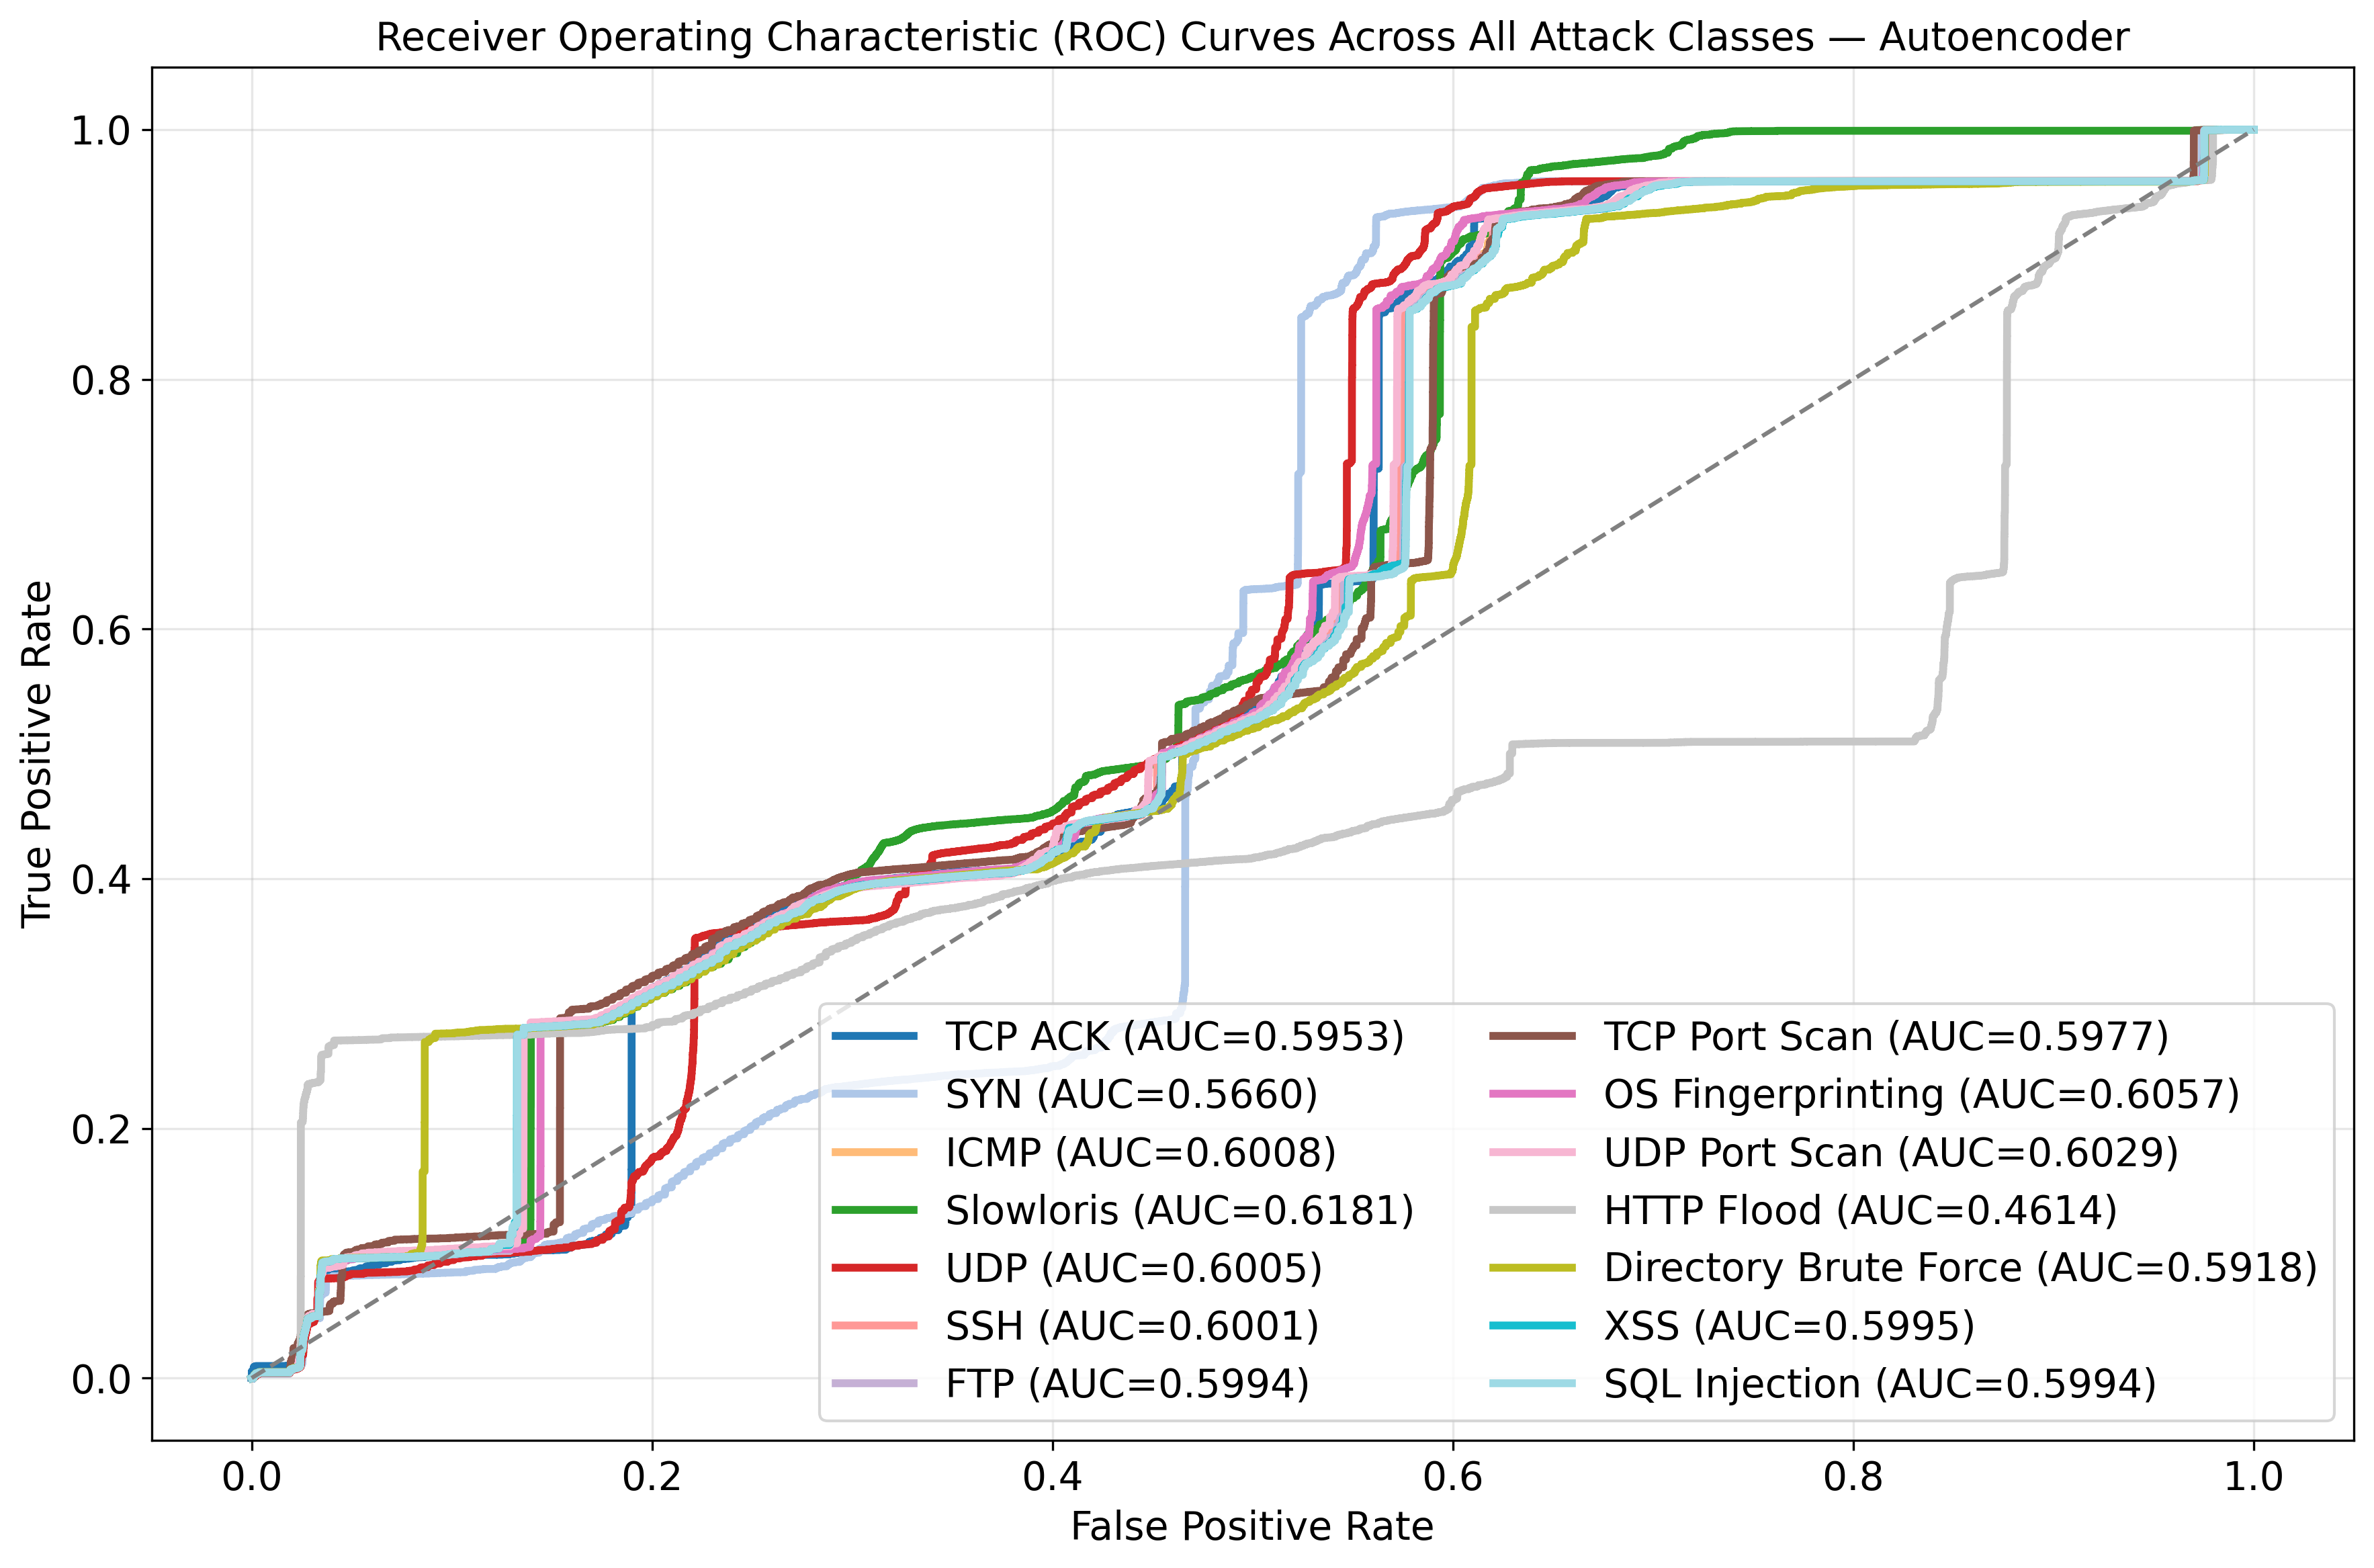

In [ ]:
# =========================================
# ROC CURVES (FULL)
# =========================================

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

plt.figure(figsize=(12, 8), dpi=300)

colors = plt.cm.get_cmap('tab20', len(roc_full_curves))

for i, (fpr, tpr, auc_val, label) in enumerate(roc_full_curves):

    pretty_label = attack_mapping.get(label, label)
    plt.plot(
        fpr,
        tpr,
        lw=2.8,
        color=colors(i),
        label=f"{pretty_label} (AUC={auc_val:.4f})"
    )

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curves Across All Attack Classes — {model_name}')
plt.grid(alpha=0.3)

plt.legend(loc='lower right', ncol=2, frameon=True)

plt.tight_layout()

os.makedirs("roc_curves", exist_ok=True)
plt.savefig(f"roc_curves/{model_name}_ALL_FULL_ROC.png", dpi=400, bbox_inches='tight')
plt.show()

/tmp/ipython-input-3364050894.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(pr_full_curves))


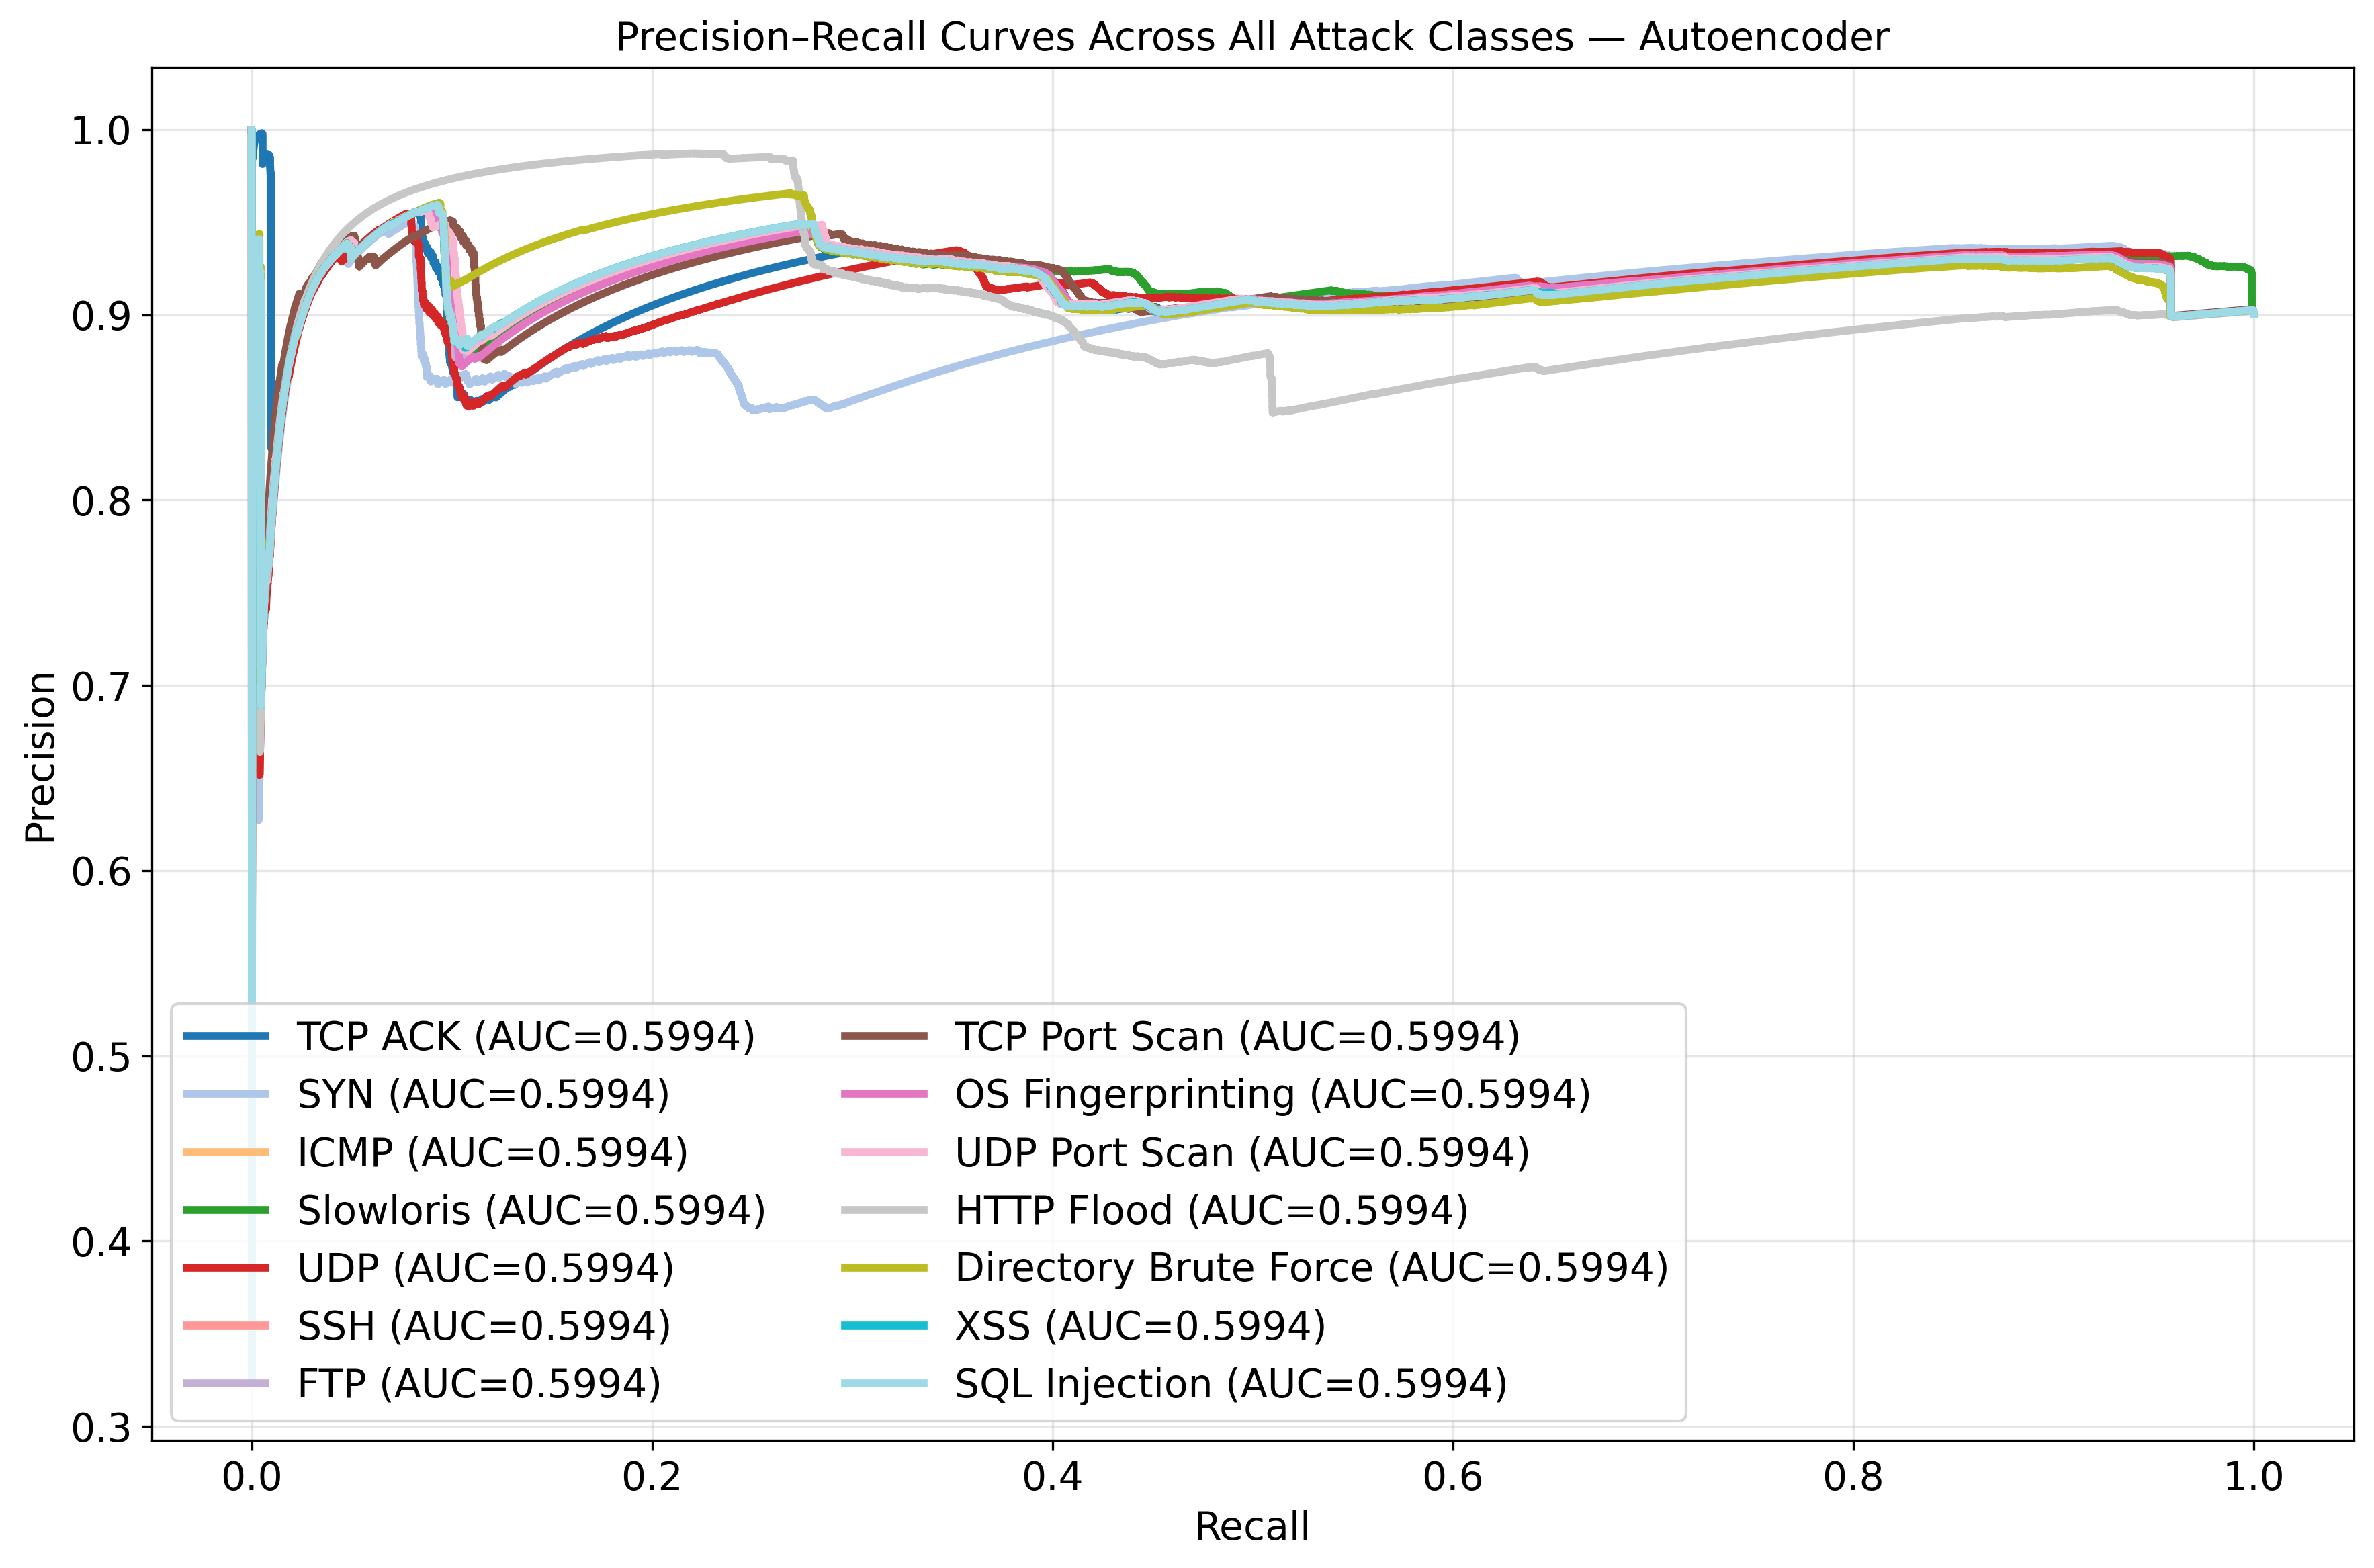

In [ ]:
# =========================================
# PR CURVES (FULL)
# =========================================

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

plt.figure(figsize=(12, 8), dpi=300)

colors = plt.cm.get_cmap('tab20', len(pr_full_curves))

for i, (precision, recall, ap_val, label) in enumerate(pr_full_curves):
    pretty_label = attack_mapping.get(label, label)
    plt.plot(
        recall,
        precision,
        lw=2.8,
        color=colors(i),
        label=f"{pretty_label} (AUC={auc_val:.4f})"
    )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision–Recall Curves Across All Attack Classes — {model_name}')
plt.grid(alpha=0.3)

plt.legend(loc='lower left', ncol=2, frameon=True)

plt.tight_layout()

os.makedirs("pr_curves", exist_ok=True)
plt.savefig(f"pr_curves/{model_name}_ALL_FULL_PR.png", dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
!pip install tabulate

In [ ]:
import pandas as pd
from tabulate import tabulate

df_resultados = pd.DataFrame(resultados_zero_day)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', '{:.4f}'.format)

print(tabulate(df_resultados, headers='keys', tablefmt='fancy_grid', showindex=False))

╒═══════════════════╤════════════╤══════════╤═════════════╤══════════╤═════════╤═════════╤══════════╤═══════════╤═════════════════╤═══════════╤══════════════════╤═══════════════╤═════════════╤════════════╤═══════════════╤═══════════════╕
│ Attack Zero-Day   │   Accuracy │       F1 │   Precision │   Recall │    Time │     CPU │   Memory │    Energy │   ZD - Accuracy │   ZD - F1 │   ZD - Precision │   ZD - Recall │   ZD - Time │   ZD - CPU │   ZD - Memory │   ZD - Energy │
╞═══════════════════╪════════════╪══════════╪═════════════╪══════════╪═════════╪═════════╪══════════╪═══════════╪═════════════════╪═══════════╪══════════════════╪═══════════════╪═════════════╪════════════╪═══════════════╪═══════════════╡
│ tcp_ack           │   0.389446 │ 0.506475 │    0.930399 │ 0.34794  │ 16.4954 │ 3.4     │  4448.52 │  5186.68  │       0.251478  │  0.40189  │                1 │     0.251478  │     3.53561 │   1.02727  │       4416.63 │      30.6628  │
├───────────────────┼────────────┼──────────┼───

In [ ]:
df_resultados.to_csv('resultados_zero_day_formatado.csv', index=False, float_format='%.4f')

In [ ]:
df_train = pd.DataFrame(train_csv)
print(tabulate(df_train, headers='keys', tablefmt='fancy_grid', showindex=False))

╒═══════════════════╤════════════════════╤═════════════════╤═════════════════╤══════════════════╕
│ attack            │   total_time_train │   avg_cpu_train │   avg_mem_train │     energy_train │
╞═══════════════════╪════════════════════╪═════════════════╪═════════════════╪══════════════════╡
│ tcp_ack           │            930.362 │           2.605 │         4091.56 │ 131573           │
├───────────────────┼────────────────────┼─────────────────┼─────────────────┼──────────────────┤
│ syn               │            507.12  │           2.46  │         4403.08 │  60395.8         │
├───────────────────┼────────────────────┼─────────────────┼─────────────────┼──────────────────┤
│ icmp              │            207.748 │           4.63  │         4945.98 │ 164956           │
├───────────────────┼────────────────────┼─────────────────┼─────────────────┼──────────────────┤
│ slowloris         │            182.923 │           8.78  │         5093.01 │ 990473           │
├───────────────────